# ANÁLISIS ESPECTRAL

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import math
from scipy.stats import moment
from fatiguepy import *
from scipy.fft import fft, fftfreq

## Visión inicial

He extraido varios espectros de Heave, Surge y Sway de forma manual en SeaFEM. Voy a agrupar todas las amplitudes en 3 dataframes, el mismo número de movimientos que estoy analizando

In [2]:
path = rf'D:\arturo_sim\simulaciones\acoplado\espectros'
movements = ['Heave','Surge','Sway']
dataframes_heave = {}
dataframes_surge = {}
dataframes_sway = {}

for mov in movements:
    direc = os.listdir(os.path.join(path,mov))
    for file in direc:
        file_path = os.path.join(path, mov, file)
        df = pd.read_excel(file_path, header=1).drop(0)

        # Almaceno los resultados del número de simulaciones empleado
        if mov == 'Heave':
            dataframes_heave[f'{file}'] = df
        elif mov == 'Surge':
            dataframes_surge[f'{file}'] = df
        else:
            dataframes_sway[f'{file}'] = df

In [3]:
dataframes_heave['oc4__Hs1__Tp2__dir1__1.xlsx']

,Frequencies),Amplitude
1,0.001221,0.000103
2,0.002441,0.000107
3,0.003662,0.000107
4,0.004883,0.000112
5,0.006104,0.000121
...,...,...
4092,4.995117,0.000021
4093,4.996338,0.000021
4094,4.997559,0.000021
4095,4.998779,0.000021


In [4]:
df_heave = pd.concat(dataframes_heave.values(), axis=1)
df_surge = pd.concat(dataframes_surge.values(), axis=1)
df_sway = pd.concat(dataframes_sway.values(), axis=1)

In [185]:
df_surge

,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,...,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude
1,0.001221,0.033272,0.001221,0.036576,0.001221,0.031510,0.001221,0.034849,0.001221,0.030763,...,0.001221,0.039391,0.001221,0.028638,0.001221,0.032087,0.001221,0.029900,0.001221,0.033217
2,0.002441,0.035605,0.002441,0.034914,0.002441,0.034181,0.002441,0.033715,0.002441,0.033645,...,0.002441,0.037237,0.002441,0.032214,0.002441,0.032251,0.002441,0.032776,0.002441,0.032377
3,0.003662,0.026814,0.003662,0.024267,0.003662,0.026069,0.003662,0.023820,0.003662,0.025837,...,0.003662,0.024930,0.003662,0.024989,0.003662,0.023474,0.003662,0.025224,0.003662,0.023083
4,0.004883,0.018362,0.004883,0.015885,0.004883,0.018022,0.004883,0.015827,0.004883,0.017819,...,0.004883,0.016503,0.004883,0.015914,0.004883,0.014137,0.004883,0.019262,0.004883,0.017280
5,0.006104,0.013490,0.006104,0.011310,0.006104,0.013321,0.006104,0.011389,0.006104,0.013478,...,0.006104,0.011943,0.006104,0.013676,0.006104,0.012201,0.006104,0.013485,0.006104,0.011772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4092,4.995117,0.000034,4.995117,0.000030,4.995117,0.000016,4.995117,0.000012,4.995117,0.000010,...,4.995117,0.000015,4.995117,0.000068,4.995117,0.000073,4.995117,0.000056,4.995117,0.000051
4093,4.996338,0.000034,4.996338,0.000030,4.996338,0.000016,4.996338,0.000012,4.996338,0.000010,...,4.996338,0.000015,4.996338,0.000068,4.996338,0.000073,4.996338,0.000056,4.996338,0.000051
4094,4.997559,0.000034,4.997559,0.000030,4.997559,0.000016,4.997559,0.000012,4.997559,0.000010,...,4.997559,0.000015,4.997559,0.000068,4.997559,0.000073,4.997559,0.000056,4.997559,0.000051
4095,4.998779,0.000035,4.998779,0.000030,4.998779,0.000016,4.998779,0.000012,4.998779,0.000010,...,4.998779,0.000015,4.998779,0.000068,4.998779,0.000073,4.998779,0.000056,4.998779,0.000051


In [186]:
df_sway

,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,...,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude
1,0.001221,0.030334,0.001221,0.032021,0.001221,0.031693,0.001221,0.033532,0.001221,0.031466,...,0.001221,0.032885,0.001221,0.032987,0.001221,0.034961,0.001221,0.028046,0.001221,0.029344
2,0.002441,0.014037,0.002441,0.008399,0.002441,0.016277,0.002441,0.010614,0.002441,0.015913,...,0.002441,0.009692,0.002441,0.018363,0.002441,0.012693,0.002441,0.009830,0.002441,0.004556
3,0.003662,0.006689,0.003662,0.001351,0.003662,0.008675,0.003662,0.003428,0.003662,0.008350,...,0.003662,0.003344,0.003662,0.010662,0.003662,0.005563,0.003662,0.003655,0.003662,0.003639
4,0.004883,0.004232,0.004883,0.000076,0.004883,0.005937,0.004883,0.002172,0.004883,0.005595,...,0.004883,0.001383,0.004883,0.007421,0.004883,0.003994,0.004883,0.002119,0.004883,0.003082
5,0.006104,0.003069,0.006104,0.000471,0.006104,0.004526,0.006104,0.001818,0.006104,0.004254,...,0.006104,0.000944,0.006104,0.006330,0.006104,0.004039,0.006104,0.003866,0.006104,0.004303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4092,4.995117,0.000002,4.995117,0.000005,4.995117,0.000019,4.995117,0.000012,4.995117,0.000009,...,4.995117,0.000052,4.995117,0.000015,4.995117,0.000009,4.995117,0.000076,4.995117,0.000082
4093,4.996338,0.000002,4.996338,0.000005,4.996338,0.000019,4.996338,0.000012,4.996338,0.000009,...,4.996338,0.000052,4.996338,0.000015,4.996338,0.000009,4.996338,0.000076,4.996338,0.000082
4094,4.997559,0.000002,4.997559,0.000005,4.997559,0.000019,4.997559,0.000012,4.997559,0.000009,...,4.997559,0.000052,4.997559,0.000015,4.997559,0.000009,4.997559,0.000076,4.997559,0.000082
4095,4.998779,0.000002,4.998779,0.000005,4.998779,0.000019,4.998779,0.000012,4.998779,0.000009,...,4.998779,0.000052,4.998779,0.000015,4.998779,0.000009,4.998779,0.000076,4.998779,0.000082


Como el rango de frecuencias es el mismo en todas las simulaciones, me cargo las columnas sobrantes

In [187]:
df_freq = df_surge.iloc[:,0]
df_surge = df_surge.drop(df_surge.filter(like='Frequencies)').columns, axis=1)
df_surge.insert(0,'Frequency',df_freq)

In [188]:
df_surge

,Frequency,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude
1,0.001221,0.033272,0.036576,0.031510,0.034849,0.030763,0.034123,0.031093,0.034430,0.029995,0.033380,0.036109,0.039391,0.028638,0.032087,0.029900,0.033217
2,0.002441,0.035605,0.034914,0.034181,0.033715,0.033645,0.033300,0.033795,0.033369,0.032627,0.032357,0.038216,0.037237,0.032214,0.032251,0.032776,0.032377
3,0.003662,0.026814,0.024267,0.026069,0.023820,0.025837,0.023754,0.025826,0.023631,0.026661,0.024541,0.027857,0.024930,0.024989,0.023474,0.025224,0.023083
4,0.004883,0.018362,0.015885,0.018022,0.015827,0.017819,0.015748,0.018065,0.015935,0.018195,0.016229,0.019338,0.016503,0.015914,0.014137,0.019262,0.017280
5,0.006104,0.013490,0.011310,0.013321,0.011389,0.013478,0.011670,0.013265,0.011394,0.013660,0.011942,0.014414,0.011943,0.013676,0.012201,0.013485,0.011772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4092,4.995117,0.000034,0.000030,0.000016,0.000012,0.000010,0.000015,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000073,0.000056,0.000051
4093,4.996338,0.000034,0.000030,0.000016,0.000012,0.000010,0.000015,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000073,0.000056,0.000051
4094,4.997559,0.000034,0.000030,0.000016,0.000012,0.000010,0.000014,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000073,0.000056,0.000051
4095,4.998779,0.000035,0.000030,0.000016,0.000012,0.000010,0.000014,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000073,0.000056,0.000051


Les cambio el nombre de las amplitudes por el de los ficheros, que tienen la nomenclatura

In [189]:
path_surge = rf'D:\arturo_sim\simulaciones\acoplado\espectros\Surge'
lista_archivos = os.listdir(path_surge)

if len(lista_archivos) == (len(df_surge.columns) - 1):
    df_surge.columns = ['Frequency'] + lista_archivos

In [190]:
df_surge

,Frequency,oc4__Hs1__Tp2__dir1__1.xlsx,oc4__Hs1__Tp2__dir1__2.xlsx,oc4__Hs1__Tp2__dir4__1.xlsx,oc4__Hs1__Tp2__dir4__2.xlsx,oc4__Hs1__Tp3__dir1__1.xlsx,oc4__Hs1__Tp3__dir1__2.xlsx,oc4__Hs1__Tp3__dir4__1.xlsx,oc4__Hs1__Tp3__dir4__2.xlsx,oc4__Hs1__Tp4__dir1__1.xlsx,oc4__Hs1__Tp4__dir1__2.xlsx,oc4__Hs1__Tp4__dir4__1.xlsx,oc4__Hs1__Tp4__dir4__2.xlsx,oc4__Hs2__Tp3__dir1__1.xlsx,oc4__Hs2__Tp3__dir1__2.xlsx,oc4__Hs2__Tp3__dir4__1.xlsx,oc4__Hs2__Tp3__dir4__2.xlsx
1,0.001221,0.033272,0.036576,0.031510,0.034849,0.030763,0.034123,0.031093,0.034430,0.029995,0.033380,0.036109,0.039391,0.028638,0.032087,0.029900,0.033217
2,0.002441,0.035605,0.034914,0.034181,0.033715,0.033645,0.033300,0.033795,0.033369,0.032627,0.032357,0.038216,0.037237,0.032214,0.032251,0.032776,0.032377
3,0.003662,0.026814,0.024267,0.026069,0.023820,0.025837,0.023754,0.025826,0.023631,0.026661,0.024541,0.027857,0.024930,0.024989,0.023474,0.025224,0.023083
4,0.004883,0.018362,0.015885,0.018022,0.015827,0.017819,0.015748,0.018065,0.015935,0.018195,0.016229,0.019338,0.016503,0.015914,0.014137,0.019262,0.017280
5,0.006104,0.013490,0.011310,0.013321,0.011389,0.013478,0.011670,0.013265,0.011394,0.013660,0.011942,0.014414,0.011943,0.013676,0.012201,0.013485,0.011772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4092,4.995117,0.000034,0.000030,0.000016,0.000012,0.000010,0.000015,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000073,0.000056,0.000051
4093,4.996338,0.000034,0.000030,0.000016,0.000012,0.000010,0.000015,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000073,0.000056,0.000051
4094,4.997559,0.000034,0.000030,0.000016,0.000012,0.000010,0.000014,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000073,0.000056,0.000051
4095,4.998779,0.000035,0.000030,0.000016,0.000012,0.000010,0.000014,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000073,0.000056,0.000051


In [191]:
df_surge.describe()

,Frequency,oc4__Hs1__Tp2__dir1__1.xlsx,oc4__Hs1__Tp2__dir1__2.xlsx,oc4__Hs1__Tp2__dir4__1.xlsx,oc4__Hs1__Tp2__dir4__2.xlsx,oc4__Hs1__Tp3__dir1__1.xlsx,oc4__Hs1__Tp3__dir1__2.xlsx,oc4__Hs1__Tp3__dir4__1.xlsx,oc4__Hs1__Tp3__dir4__2.xlsx,oc4__Hs1__Tp4__dir1__1.xlsx,oc4__Hs1__Tp4__dir1__2.xlsx,oc4__Hs1__Tp4__dir4__1.xlsx,oc4__Hs1__Tp4__dir4__2.xlsx,oc4__Hs2__Tp3__dir1__1.xlsx,oc4__Hs2__Tp3__dir1__2.xlsx,oc4__Hs2__Tp3__dir4__1.xlsx,oc4__Hs2__Tp3__dir4__2.xlsx
count,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000
mean,2.500610,0.000349,0.000332,0.000215,0.000198,0.000388,0.000393,0.000279,0.000262,0.000565,0.000573,0.000356,0.000339,0.001115,0.001123,0.000610,0.000595
std,1.443552,0.002561,0.002547,0.001857,0.001842,0.003967,0.003956,0.002844,0.002838,0.005292,0.005283,0.003711,0.003700,0.011139,0.011133,0.007833,0.007833
min,0.001221,0.000034,0.000030,0.000016,0.000012,0.000010,0.000014,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000072,0.000056,0.000051
25%,1.250916,0.000037,0.000032,0.000018,0.000013,0.000011,0.000016,0.000036,0.000031,0.000024,0.000029,0.000021,0.000016,0.000074,0.000079,0.000061,0.000056
50%,2.500610,0.000049,0.000042,0.000023,0.000017,0.000014,0.000020,0.000046,0.000040,0.000032,0.000038,0.000027,0.000021,0.000096,0.000103,0.000079,0.000073
75%,3.750305,0.000091,0.000079,0.000043,0.000031,0.000026,0.000038,0.000086,0.000074,0.000059,0.000071,0.000051,0.000039,0.000178,0.000190,0.000147,0.000135
max,5.000000,0.087430,0.087365,0.067710,0.067758,0.118029,0.117789,0.121231,0.121437,0.133109,0.132918,0.117248,0.117412,0.339400,0.339131,0.352595,0.352776


## Representaciones del comportamiento de surge

veamos la diferencia entre un espectro en un caso saludable y en un caso con garreo

representación con dirección del oleaje a 0º

<Figure size 2000x1000 with 0 Axes>

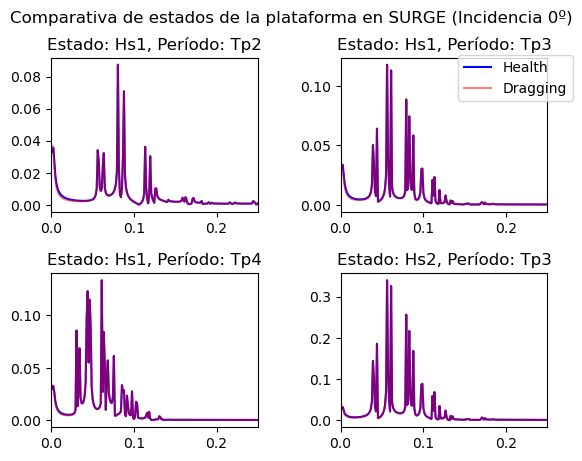

In [192]:
plt.figure(figsize=(20, 10))
fig, axs = plt.subplots(nrows=2, ncols=2)

# Desempaqueta los ejes en variables individuales
hs1_tp2, hs1_tp3, hs1_tp4, hs2_tp3 = axs.flatten()


hs1_tp2.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Health')
hs1_tp2.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp2.set_xlim(0,0.25)
hs1_tp2.set_title('Estado: Hs1, Período: Tp2')


hs1_tp3.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp3__dir1__1.xlsx'], color = 'b', label = 'Health')
hs1_tp3.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp3__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp3.set_xlim(0,0.25)
hs1_tp3.set_title('Estado: Hs1, Período: Tp3')


hs1_tp4.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp4__dir1__1.xlsx'], color = 'b', label = 'Health')
hs1_tp4.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp4__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp4.set_xlim(0,0.25)
hs1_tp4.set_title('Estado: Hs1, Período: Tp4')


hs2_tp3.plot(df_surge['Frequency'],df_surge['oc4__Hs2__Tp3__dir1__1.xlsx'], color = 'b', label = 'Health')
hs2_tp3.plot(df_surge['Frequency'],df_surge['oc4__Hs2__Tp3__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs2_tp3.set_xlim(0,0.25)
hs2_tp3.set_title('Estado: Hs2, Período: Tp3')


fig.subplots_adjust(hspace=0.4, wspace=0.4)
fig.suptitle('Comparativa de estados de la plataforma en SURGE (Incidencia 0º)')
fig.legend(['Health', 'Dragging'], loc='upper center', bbox_to_anchor=(0.85, 0.9))

representación con dirección del oleaje a 60º

representación con dirección del oleaje a 90º

representación con dirección del oleaje a 120º

<Figure size 2000x1000 with 0 Axes>

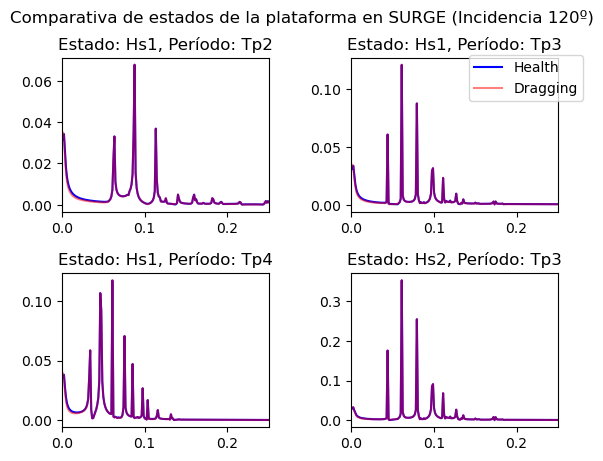

In [193]:
plt.figure(figsize=(20, 10))
fig, axs = plt.subplots(nrows=2, ncols=2)

# Desempaqueta los ejes en variables individuales
hs1_tp2, hs1_tp3, hs1_tp4, hs2_tp3 = axs.flatten()


hs1_tp2.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir4__1.xlsx'], color = 'b', label = 'Health')
hs1_tp2.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir4__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp2.set_xlim(0,0.25)
hs1_tp2.set_title('Estado: Hs1, Período: Tp2')


hs1_tp3.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp3__dir4__1.xlsx'], color = 'b', label = 'Health')
hs1_tp3.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp3__dir4__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp3.set_xlim(0,0.25)
hs1_tp3.set_title('Estado: Hs1, Período: Tp3')


hs1_tp4.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp4__dir4__1.xlsx'], color = 'b', label = 'Health')
hs1_tp4.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp4__dir4__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp4.set_xlim(0,0.25)
hs1_tp4.set_title('Estado: Hs1, Período: Tp4')


hs2_tp3.plot(df_surge['Frequency'],df_surge['oc4__Hs2__Tp3__dir4__1.xlsx'], color = 'b', label = 'Health')
hs2_tp3.plot(df_surge['Frequency'],df_surge['oc4__Hs2__Tp3__dir4__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs2_tp3.set_xlim(0,0.25)
hs2_tp3.set_title('Estado: Hs2, Período: Tp3')


fig.subplots_adjust(hspace=0.4, wspace=0.4)
fig.suptitle('Comparativa de estados de la plataforma en SURGE (Incidencia 120º)')
fig.legend(['Health', 'Dragging'], loc='upper center', bbox_to_anchor=(0.85, 0.9))

representación con dirección del oleaje a 180º

## Representaciones del comportamiento de sway

In [194]:
df_freq = df_surge.iloc[:,0]
df_sway = df_sway.drop(df_sway.filter(like='Frequencies)').columns, axis=1)
df_sway.insert(0,'Frequency',df_freq)

In [195]:
path_sway = rf'D:\arturo_sim\simulaciones\acoplado\espectros\Sway'
lista_archivos = os.listdir(path_sway)

if len(lista_archivos) == (len(df_sway.columns) - 1):
    df_sway.columns = ['Frequency'] + lista_archivos

In [196]:
df_sway

,Frequency,oc4__Hs1__Tp2__dir1__1.xlsx,oc4__Hs1__Tp2__dir1__2.xlsx,oc4__Hs1__Tp2__dir4__1.xlsx,oc4__Hs1__Tp2__dir4__2.xlsx,oc4__Hs1__Tp3__dir1__1.xlsx,oc4__Hs1__Tp3__dir1__2.xlsx,oc4__Hs1__Tp3__dir4__1.xlsx,oc4__Hs1__Tp3__dir4__2.xlsx,oc4__Hs1__Tp4__dir1__1.xlsx,oc4__Hs1__Tp4__dir1__2.xlsx,oc4__Hs1__Tp4__dir4__1.xlsx,oc4__Hs1__Tp4__dir4__2.xlsx,oc4__Hs2__Tp3__dir1__1.xlsx,oc4__Hs2__Tp3__dir1__2.xlsx,oc4__Hs2__Tp3__dir4__1.xlsx,oc4__Hs2__Tp3__dir4__2.xlsx
1,0.001221,0.030334,0.032021,0.031693,0.033532,0.031466,0.033279,0.029728,0.031346,0.028588,0.030018,0.031089,0.032885,0.032987,0.034961,0.028046,0.029344
2,0.002441,0.014037,0.008399,0.016277,0.010614,0.015913,0.010245,0.013053,0.007452,0.010797,0.005246,0.015324,0.009692,0.018363,0.012693,0.009830,0.004556
3,0.003662,0.006689,0.001351,0.008675,0.003428,0.008350,0.003096,0.005891,0.000920,0.003954,0.002674,0.008715,0.003344,0.010662,0.005563,0.003655,0.003639
4,0.004883,0.004232,0.000076,0.005937,0.002172,0.005595,0.001813,0.003740,0.000927,0.003101,0.003543,0.005514,0.001383,0.007421,0.003994,0.002119,0.003082
5,0.006104,0.003069,0.000471,0.004526,0.001818,0.004254,0.001543,0.002944,0.001400,0.003222,0.003950,0.004224,0.000944,0.006330,0.004039,0.003866,0.004303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4092,4.995117,0.000002,0.000005,0.000019,0.000012,0.000009,0.000002,0.000023,0.000030,0.000032,0.000025,0.000046,0.000052,0.000015,0.000009,0.000076,0.000082
4093,4.996338,0.000002,0.000005,0.000019,0.000012,0.000009,0.000002,0.000023,0.000030,0.000032,0.000025,0.000046,0.000052,0.000015,0.000009,0.000076,0.000082
4094,4.997559,0.000002,0.000005,0.000019,0.000012,0.000009,0.000002,0.000023,0.000030,0.000032,0.000025,0.000045,0.000052,0.000015,0.000009,0.000076,0.000082
4095,4.998779,0.000002,0.000005,0.000019,0.000012,0.000009,0.000002,0.000023,0.000030,0.000032,0.000025,0.000045,0.000052,0.000015,0.000009,0.000076,0.000082


<Figure size 2000x1000 with 0 Axes>

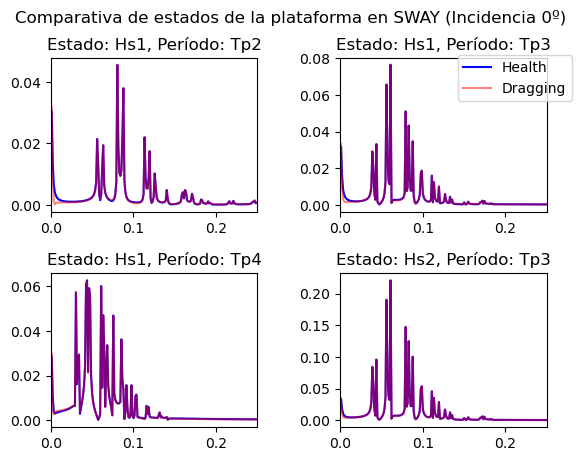

In [197]:
plt.figure(figsize=(20, 10))
fig, axs = plt.subplots(nrows=2, ncols=2)

# Desempaqueta los ejes en variables individuales
hs1_tp2, hs1_tp3, hs1_tp4, hs2_tp3 = axs.flatten()


hs1_tp2.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Health')
hs1_tp2.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp2.set_xlim(0,0.25)
hs1_tp2.set_title('Estado: Hs1, Período: Tp2')


hs1_tp3.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp3__dir1__1.xlsx'], color = 'b', label = 'Health')
hs1_tp3.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp3__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp3.set_xlim(0,0.25)
hs1_tp3.set_title('Estado: Hs1, Período: Tp3')


hs1_tp4.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp4__dir1__1.xlsx'], color = 'b', label = 'Health')
hs1_tp4.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp4__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp4.set_xlim(0,0.25)
hs1_tp4.set_title('Estado: Hs1, Período: Tp4')


hs2_tp3.plot(df_sway['Frequency'],df_sway['oc4__Hs2__Tp3__dir1__1.xlsx'], color = 'b', label = 'Health')
hs2_tp3.plot(df_sway['Frequency'],df_sway['oc4__Hs2__Tp3__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs2_tp3.set_xlim(0,0.25)
hs2_tp3.set_title('Estado: Hs2, Período: Tp3')


fig.subplots_adjust(hspace=0.4, wspace=0.4)
fig.suptitle('Comparativa de estados de la plataforma en SWAY (Incidencia 0º)')
fig.legend(['Health', 'Dragging'], loc='upper center', bbox_to_anchor=(0.85, 0.9))

<Figure size 2000x1000 with 0 Axes>

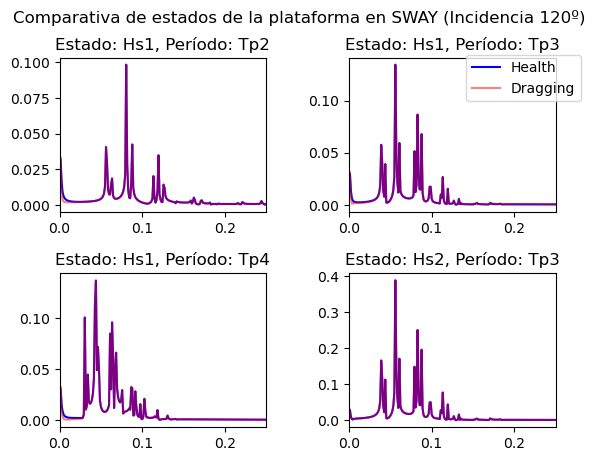

In [198]:
plt.figure(figsize=(20, 10))
fig, axs = plt.subplots(nrows=2, ncols=2)

# Desempaqueta los ejes en variables individuales
hs1_tp2, hs1_tp3, hs1_tp4, hs2_tp3 = axs.flatten()


hs1_tp2.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir4__1.xlsx'], color = 'b', label = 'Health')
hs1_tp2.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir4__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp2.set_xlim(0,0.25)
hs1_tp2.set_title('Estado: Hs1, Período: Tp2')


hs1_tp3.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp3__dir4__1.xlsx'], color = 'b', label = 'Health')
hs1_tp3.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp3__dir4__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp3.set_xlim(0,0.25)
hs1_tp3.set_title('Estado: Hs1, Período: Tp3')


hs1_tp4.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp4__dir4__1.xlsx'], color = 'b', label = 'Health')
hs1_tp4.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp4__dir4__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp4.set_xlim(0,0.25)
hs1_tp4.set_title('Estado: Hs1, Período: Tp4')


hs2_tp3.plot(df_sway['Frequency'],df_sway['oc4__Hs2__Tp3__dir4__1.xlsx'], color = 'b', label = 'Health')
hs2_tp3.plot(df_sway['Frequency'],df_sway['oc4__Hs2__Tp3__dir4__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs2_tp3.set_xlim(0,0.25)
hs2_tp3.set_title('Estado: Hs2, Período: Tp3')


fig.subplots_adjust(hspace=0.4, wspace=0.4)
fig.suptitle('Comparativa de estados de la plataforma en SWAY (Incidencia 120º)')
fig.legend(['Health', 'Dragging'], loc='upper center', bbox_to_anchor=(0.85, 0.9))

## Prueba con análisis no lineal

Como los espectros se mantienen iguales a pesar de mover el anchor point, veamos como se comporta en un análisis de segundo orden

In [199]:
path = rf'D:\arturo_sim\simulaciones\acoplado\espectros_no_lineal'
movements = ['Surge','Sway']
#dataframes_heave = {}
dataframes_surge_2 = {}
dataframes_sway_2 = {}

for mov in movements:
    direc = os.listdir(os.path.join(path,mov))
    for file in direc:
        file_path = os.path.join(path, mov, file)
        df = pd.read_excel(file_path, header=1).drop(0)

        # Almaceno los resultados del número de simulaciones empleado
        #if mov == 'Heave':
            #dataframes_heave[f'{file}'] = df
        if mov == 'Surge':
            dataframes_surge_2[f'{file}'] = df
        else:
            dataframes_sway_2[f'{file}'] = df

In [200]:
dataframes_surge_2['oc4__Hs1__Tp2__dir1__1.xlsx']

,Frequencies),Amplitude
1,0.001221,0.033272
2,0.002441,0.035605
3,0.003662,0.026814
4,0.004883,0.018362
5,0.006104,0.013490
...,...,...
4092,4.995117,0.000034
4093,4.996338,0.000034
4094,4.997559,0.000034
4095,4.998779,0.000035


In [201]:
df_surge_2 = pd.concat(dataframes_surge_2.values(), axis=1)
df_sway_2 = pd.concat(dataframes_sway_2.values(), axis=1)

In [202]:
df_freq = df_surge_2.iloc[:,0]
df_surge_2 = df_surge_2.drop(df_surge_2.filter(like='Frequencies)').columns, axis=1)
df_surge_2.insert(0,'Frequency',df_freq)

In [203]:
path_surge_2 = rf'D:\arturo_sim\simulaciones\acoplado\espectros_no_lineal\Surge'
lista_archivos = os.listdir(path_surge_2)

if len(lista_archivos) == (len(df_surge_2.columns) - 1):
    df_surge_2.columns = ['Frequency'] + lista_archivos

In [204]:
df_surge_2

,Frequency,oc4__Hs1__Tp2__dir1__1.xlsx,oc4__Hs1__Tp2__dir1__2.xlsx
1,0.001221,0.033272,0.036576
2,0.002441,0.035605,0.034914
3,0.003662,0.026814,0.024267
4,0.004883,0.018362,0.015885
5,0.006104,0.013490,0.011310
...,...,...,...
4092,4.995117,0.000034,0.000030
4093,4.996338,0.000034,0.000030
4094,4.997559,0.000034,0.000030
4095,4.998779,0.000035,0.000030


Comparemos diferencias entre espectros saludables lineal y no lineal.

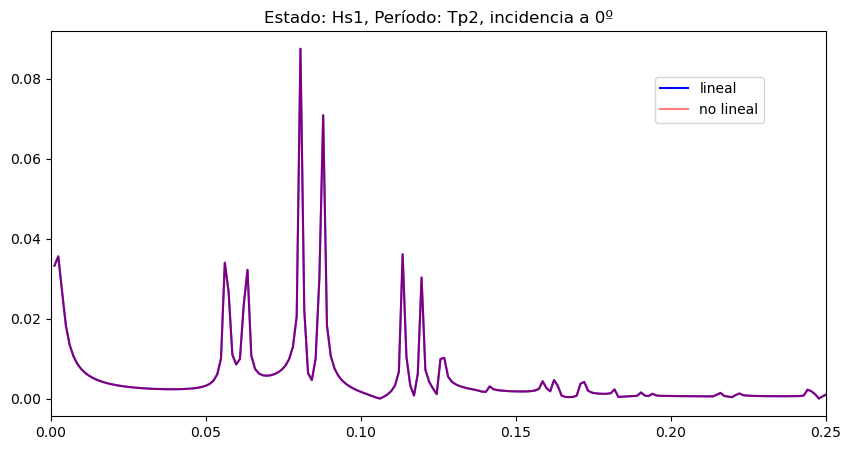

In [205]:
plt.figure(figsize=(10, 5))

plt.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'lineal')
plt.plot(df_surge_2['Frequency'],df_surge_2['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'r', label = 'no lineal',alpha=0.5)
plt.xlim(0,0.25)
plt.title('Estado: Hs1, Período: Tp2, incidencia a 0º')
plt.legend(['lineal', 'no lineal'], loc='upper center', bbox_to_anchor=(0.85, 0.9))

Comparación de estados con surge

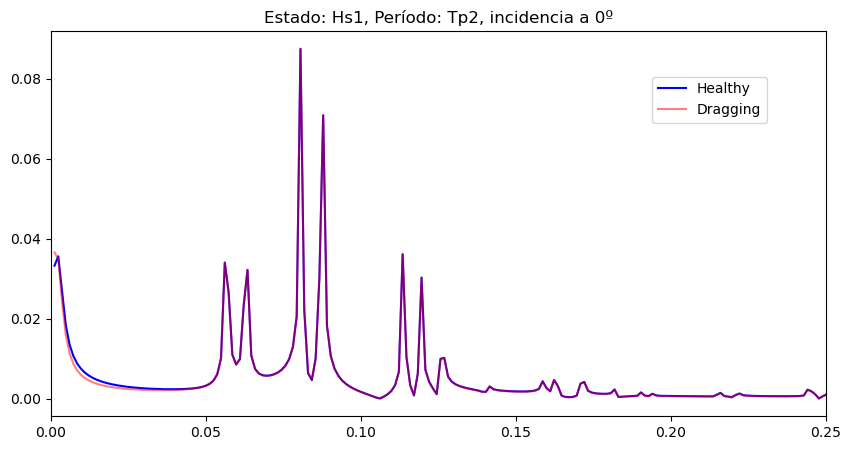

In [206]:
plt.figure(figsize=(10, 5))

plt.plot(df_surge_2['Frequency'],df_surge_2['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
plt.plot(df_surge_2['Frequency'],df_surge_2['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
plt.xlim(0,0.25)
plt.title('Estado: Hs1, Período: Tp2, incidencia a 0º')
plt.legend(['Healthy', 'Dragging'], loc='upper center', bbox_to_anchor=(0.85, 0.9))

## Detección de límite del garreo

### Surge

Como probando con 5 m de desplazamiento no se han visto grandes cambios, vamos a detectar una distancia límite donde los espectros difieran con mayor claridad

In [96]:
path = rf'D:\arturo_sim\simulaciones\acoplado\analisis_limite_garreo'
movements = ['Surge','Sway']
dataframes_surge = {}
dataframes_sway = {}

for mov in movements:
    direc = os.listdir(os.path.join(path,mov))
    for file in direc:
        file_path = os.path.join(path, mov, file)
        df = pd.read_excel(file_path, header=1).drop(0)

        # Almaceno los resultados del número de simulaciones empleado
        if mov == 'Surge':
            dataframes_surge[f'{file}'] = df
        else:
            dataframes_sway[f'{file}'] = df

In [97]:
dataframes_surge['oc4__Hs1__Tp2__dir1__2.xlsx']

,Frequencies),Amplitude
1,0.002441,7.912032e-02
2,0.004883,3.725436e-02
3,0.007324,2.092640e-02
4,0.009766,1.454733e-02
5,0.012207,1.129185e-02
...,...,...
2044,4.990234,2.530248e-07
2045,4.992676,1.687390e-07
2046,4.995117,1.268861e-07
2047,4.997559,1.995568e-07


In [98]:
df_surge = pd.concat(dataframes_surge.values(), axis=1)
df_sway = pd.concat(dataframes_sway.values(), axis=1)

In [99]:
df_surge

,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude
1,0.002441,0.091913,0.002441,7.912032e-02,0.002441,0.087156,0.002441,0.162692,0.002441,0.208059,0.002441,0.131558,0.002441,0.061164,0.002441,0.091593,0.002441,0.089941,0.002441,0.133012
2,0.004883,0.033768,0.004883,3.725436e-02,0.004883,0.064765,0.004883,0.107065,0.004883,0.121588,0.004883,0.075295,0.004883,0.140842,0.004883,0.036320,0.004883,0.066751,0.004883,0.075804
3,0.007324,0.014195,0.007324,2.092640e-02,0.007324,0.043601,0.007324,0.072357,0.007324,0.081293,0.007324,0.049852,0.007324,0.110455,0.007324,0.017019,0.007324,0.044779,0.007324,0.049986
4,0.009766,0.007643,0.009766,1.454733e-02,0.009766,0.032668,0.009766,0.054361,0.009766,0.060900,0.009766,0.037204,0.009766,0.026779,0.009766,0.010354,0.009766,0.033401,0.009766,0.037127
5,0.012207,0.004829,0.012207,1.129185e-02,0.012207,0.026174,0.012207,0.043563,0.012207,0.048733,0.012207,0.029742,0.012207,0.033780,0.012207,0.007273,0.012207,0.026592,0.012207,0.029503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2044,4.990234,0.000028,4.990234,2.530248e-07,4.990234,0.000058,4.990234,0.000124,4.990234,0.000143,4.990234,0.000070,4.990234,0.000164,4.990234,0.000046,4.990234,0.000132,4.990234,0.000145
2045,4.992676,0.000028,4.992676,1.687390e-07,4.992676,0.000058,4.992676,0.000124,4.992676,0.000143,4.992676,0.000068,4.992676,0.000163,4.992676,0.000046,4.992676,0.000132,4.992676,0.000143
2046,4.995117,0.000028,4.995117,1.268861e-07,4.995117,0.000058,4.995117,0.000124,4.995117,0.000143,4.995117,0.000069,4.995117,0.000165,4.995117,0.000046,4.995117,0.000132,4.995117,0.000144
2047,4.997559,0.000028,4.997559,1.995568e-07,4.997559,0.000058,4.997559,0.000124,4.997559,0.000143,4.997559,0.000070,4.997559,0.000164,4.997559,0.000046,4.997559,0.000132,4.997559,0.000144


In [100]:
df_sway

,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude
1,0.002441,0.059471,0.002441,3.058180e-02,0.002441,0.092018,0.002441,0.236142,0.002441,0.301286,0.002441,0.168987,0.002441,0.094013,0.002441,0.060558,0.002441,0.090453,0.002441,0.169395
2,0.004883,0.024559,0.004883,1.024009e-02,0.004883,0.056546,0.004883,0.121604,0.004883,0.137134,0.004883,0.052974,0.004883,0.259477,0.004883,0.024737,0.004883,0.055779,0.004883,0.053834
3,0.007324,0.013993,0.007324,6.034910e-03,0.007324,0.038851,0.007324,0.080665,0.007324,0.088459,0.007324,0.027633,0.007324,0.249548,0.007324,0.013947,0.007324,0.038393,0.007324,0.028493
4,0.009766,0.009582,0.009766,4.266991e-03,0.009766,0.029476,0.009766,0.060391,0.009766,0.065534,0.009766,0.018220,0.009766,0.161761,0.009766,0.009497,0.009766,0.029191,0.009766,0.019054
5,0.012207,0.007267,0.012207,3.318906e-03,0.012207,0.023720,0.012207,0.048285,0.012207,0.052136,0.012207,0.013552,0.012207,0.104616,0.012207,0.007194,0.012207,0.023557,0.012207,0.014362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2044,4.990234,0.000037,4.990234,2.766957e-07,4.990234,0.000080,4.990234,0.000173,4.990234,0.000186,4.990234,0.000032,4.990234,0.000314,4.990234,0.000057,4.990234,0.000060,4.990234,0.000012
2045,4.992676,0.000037,4.992676,3.328908e-07,4.992676,0.000080,4.992676,0.000173,4.992676,0.000186,4.992676,0.000032,4.992676,0.000313,4.992676,0.000057,4.992676,0.000059,4.992676,0.000012
2046,4.995117,0.000037,4.995117,2.865883e-07,4.995117,0.000080,4.995117,0.000173,4.995117,0.000186,4.995117,0.000032,4.995117,0.000312,4.995117,0.000057,4.995117,0.000060,4.995117,0.000012
2047,4.997559,0.000037,4.997559,1.022289e-07,4.997559,0.000080,4.997559,0.000173,4.997559,0.000186,4.997559,0.000032,4.997559,0.000314,4.997559,0.000057,4.997559,0.000060,4.997559,0.000012


In [101]:
df_freq = df_surge.iloc[:,0]
df_surge = df_surge.drop(df_surge.filter(like='Frequencies)').columns, axis=1)
df_surge.insert(0,'Frequency',df_freq)

In [102]:
path_surge = rf'D:\arturo_sim\simulaciones\acoplado\analisis_limite_garreo\Surge'
lista_archivos = os.listdir(path_surge)

if len(lista_archivos) == (len(df_surge.columns) - 1):
    df_surge.columns = ['Frequency'] + lista_archivos

In [103]:
df_surge

,Frequency,oc4__Hs1__Tp2__dir1__1.xlsx,oc4__Hs1__Tp2__dir1__2.xlsx,oc4__Hs1__Tp2__dir1__3.xlsx,oc4__Hs1__Tp2__dir1__4.xlsx,oc4__Hs1__Tp2__dir1__5.xlsx,oc4__Hs1__Tp2__dir1__6.xlsx,oc4__Hs1__Tp2__dir1__7.xlsx,oc4__Hs1__Tp2__dir4__1.xlsx,oc4__Hs1__Tp2__dir4__3.xlsx,oc4__Hs1__Tp2__dir4__6.xlsx
1,0.002441,0.091913,7.912032e-02,0.087156,0.162692,0.208059,0.131558,0.061164,0.091593,0.089941,0.133012
2,0.004883,0.033768,3.725436e-02,0.064765,0.107065,0.121588,0.075295,0.140842,0.036320,0.066751,0.075804
3,0.007324,0.014195,2.092640e-02,0.043601,0.072357,0.081293,0.049852,0.110455,0.017019,0.044779,0.049986
4,0.009766,0.007643,1.454733e-02,0.032668,0.054361,0.060900,0.037204,0.026779,0.010354,0.033401,0.037127
5,0.012207,0.004829,1.129185e-02,0.026174,0.043563,0.048733,0.029742,0.033780,0.007273,0.026592,0.029503
...,...,...,...,...,...,...,...,...,...,...,...
2044,4.990234,0.000028,2.530248e-07,0.000058,0.000124,0.000143,0.000070,0.000164,0.000046,0.000132,0.000145
2045,4.992676,0.000028,1.687390e-07,0.000058,0.000124,0.000143,0.000068,0.000163,0.000046,0.000132,0.000143
2046,4.995117,0.000028,1.268861e-07,0.000058,0.000124,0.000143,0.000069,0.000165,0.000046,0.000132,0.000144
2047,4.997559,0.000028,1.995568e-07,0.000058,0.000124,0.000143,0.000070,0.000164,0.000046,0.000132,0.000144


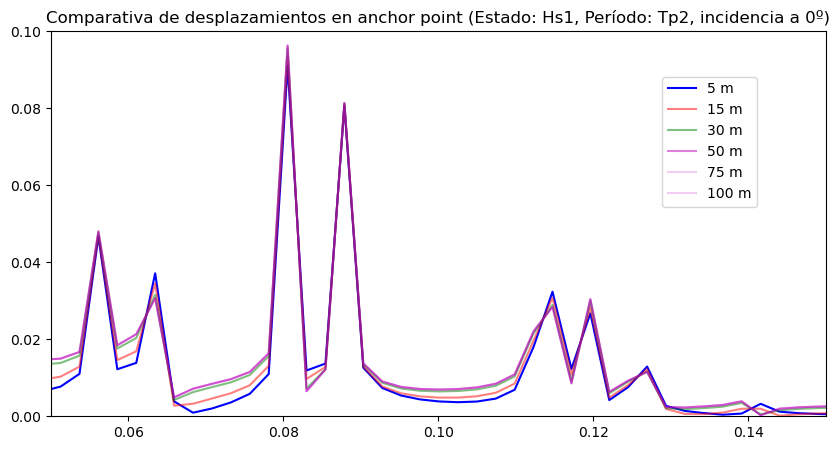

In [104]:
plt.figure(figsize=(10, 5))

plt.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'b', label = '5 m')
plt.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__3.xlsx'], color = 'r', label = '15 m',alpha=0.5)
plt.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__4.xlsx'], color = 'g', label = '30 m',alpha=0.5)
plt.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__5.xlsx'], color = 'm', label = '50 m',alpha=0.5)
plt.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__5.xlsx'], color = 'm', label = '75 m',alpha=0.2)
plt.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__5.xlsx'], color = 'm', label = '100 m',alpha=0.2)

plt.xlim(0.05,0.15)
plt.ylim(0,0.10)
plt.title('Comparativa de desplazamientos en anchor point (Estado: Hs1, Período: Tp2, incidencia a 0º)')
plt.legend(loc='upper center', bbox_to_anchor=(0.85, 0.9))

Comparativa de garreos con el caso saludable

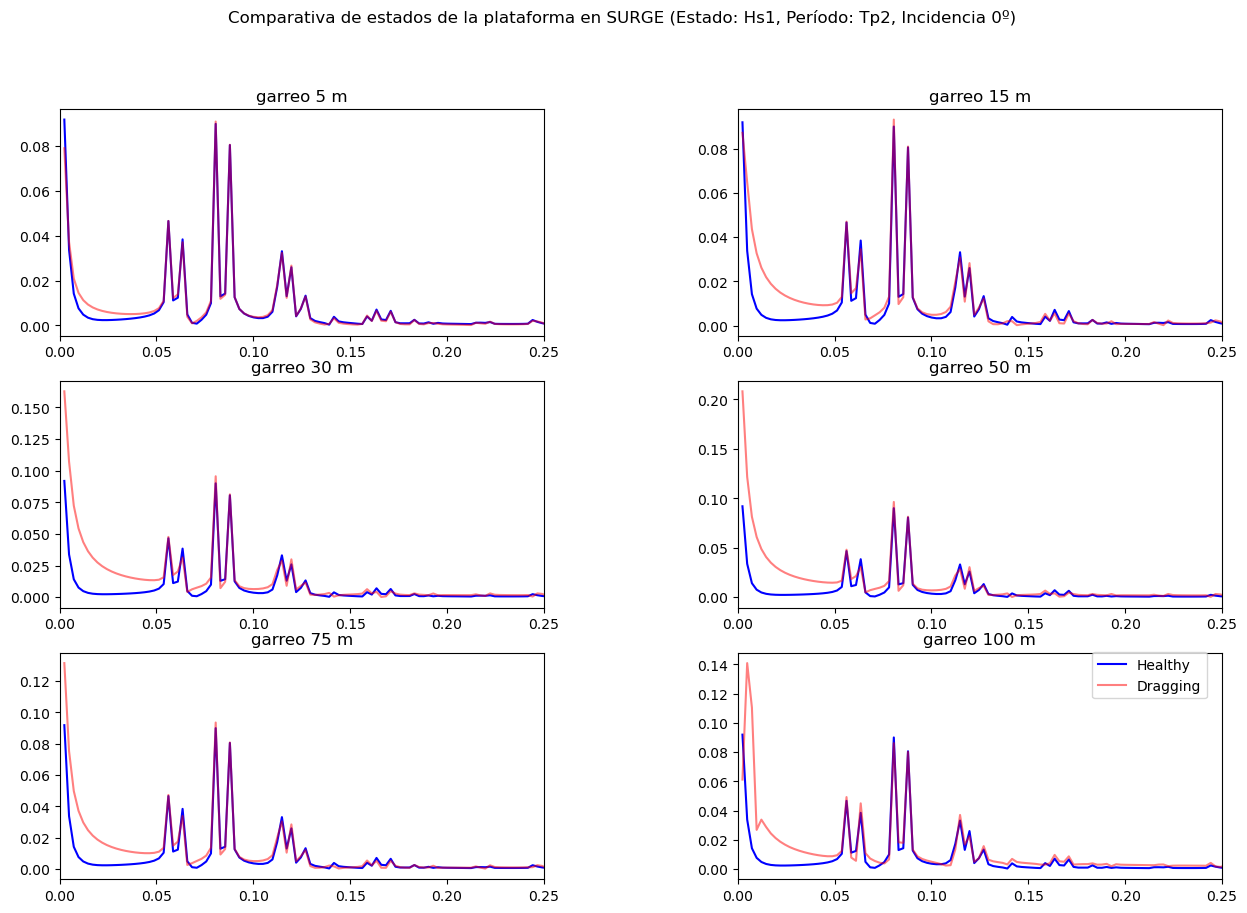

In [105]:
plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 1])

# Desempaqueta los ejes en variables individuales
garreo1 = plt.subplot(gs[0])
garreo2 = plt.subplot(gs[1])
garreo3 = plt.subplot(gs[2])
garreo4 = plt.subplot(gs[3])
garreo5 = plt.subplot(gs[4])
garreo6 = plt.subplot(gs[5])

#fig, axs = plt.subplots(nrows=2, ncols=2)

# Desempaqueta los ejes en variables individuales
#garreo1, garreo2, garreo3, garreo4 = axs.flatten()


garreo1.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo1.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo1.set_xlim(0,0.25)
garreo1.set_title('garreo 5 m')


garreo2.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo2.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__3.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo2.set_xlim(0,0.25)
garreo2.set_title('garreo 15 m')


garreo3.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo3.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__4.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo3.set_xlim(0,0.25)
garreo3.set_title('garreo 30 m')


garreo4.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo4.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__5.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo4.set_xlim(0,0.25)
garreo4.set_title('garreo 50 m')


garreo5.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo5.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__6.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo5.set_xlim(0,0.25)
garreo5.set_title('garreo 75 m')

garreo6.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo6.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__7.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo6.set_xlim(0,0.25)
garreo6.set_title('garreo 100 m')

plt.subplots_adjust(hspace=0.2, wspace=0.4)
plt.suptitle('Comparativa de estados de la plataforma en SURGE (Estado: Hs1, Período: Tp2, Incidencia 0º)')
plt.legend(['Healthy', 'Dragging'], loc='center', bbox_to_anchor=(0.85, 0.9))

Comparemos los momentos de orden 0, 2 y 4. Aumentando el orden de los momentos se pueden cuentificar mejor las diferencias.

In [152]:
columns = ['m2','m4']
stats_surge = pd.DataFrame(columns=columns)
for col in df_surge.columns[1:-3]:
    m2 = moment(df_surge[col], moment=2)
    m4 = moment(df_surge[col], moment=4)

    stats_surge.loc[col]=[m2,m4]

stats_surge.index=['healthy','5','15','30','50','75','100']

In [154]:
columns = ['m0','m2','m4']
stats_surge = pd.DataFrame(columns=columns)
freq = df_surge['Frequency'].values

for col in df_surge.columns[1:-3]:
    mov = df_surge[col].values
    m = prob_moment.Probability_Moment(mov,freq)

    m0 = m.momentn(0)
    m2 = m.momentn(2)
    m4 = m.momentn(4)

    stats_surge.loc[col]=[m0,m2,m4]

stats_surge.index=['healthy','5','15','30','50','75','100']

In [155]:
stats_surge

,m0,m2,m4
healthy,0.002231,0.056275,29.514166
5,0.002084,0.002095,0.408266
15,0.003169,0.114497,60.588998
30,0.004770,0.244759,129.787753
50,0.005307,0.282130,149.637565
75,0.003541,0.137277,72.695101
100,0.004899,0.323776,171.626504


In [60]:
momentos = ['m2','m4']
m2_dif_surge=[]
m4_dif_surge=[]

for m in momentos:
    health = stats_surge[m][0]
    for i in range(1,len(stats_surge)):
        dif = abs(stats_surge[m][i]-health)
        if m=='m2':
            m2_dif_surge.append(dif)
        else:
            m4_dif_surge.append(dif)

C:\Users\naval\AppData\Local\Temp\ipykernel_10100\2824797089.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  health = stats_surge[m][0]
C:\Users\naval\AppData\Local\Temp\ipykernel_10100\2824797089.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dif = abs(stats_surge[m][i]-health)


In [61]:
m2_dif_surge

[4.0273759897973653e-07,
 4.120987008095539e-06,
 2.2286018535377273e-05,
 3.42346902467154e-05,
 1.0454465708851405e-05,
 1.5306548393858267e-05]

In [62]:
m4_dif_surge

[1.3497900107428237e-08,
 7.687954909762567e-09,
 3.890379227293679e-07,
 1.0053221917492553e-06,
 1.3257413815952556e-07,
 2.247999877865433e-07]

### Sway

In [ ]:
df_freq = df_sway.iloc[:,0]
df_sway = df_sway.drop(df_sway.filter(like='Frequencies)').columns, axis=1)
df_sway.insert(0,'Frequency',df_freq)

In [135]:
path_sway = rf'D:\arturo_sim\simulaciones\acoplado\analisis_limite_garreo\Sway'
lista_archivos = os.listdir(path_sway)

if len(lista_archivos) == (len(df_sway.columns) - 1):
    df_sway.columns = ['Frequency'] + lista_archivos

In [136]:
df_sway

,Frequency,oc4__Hs1__Tp2__dir1__1.xlsx,oc4__Hs1__Tp2__dir1__2.xlsx,oc4__Hs1__Tp2__dir1__3.xlsx,oc4__Hs1__Tp2__dir1__4.xlsx,oc4__Hs1__Tp2__dir1__5.xlsx,oc4__Hs1__Tp2__dir1__6.xlsx,oc4__Hs1__Tp2__dir1__7.xlsx,oc4__Hs1__Tp2__dir4__1.xlsx,oc4__Hs1__Tp2__dir4__3.xlsx,oc4__Hs1__Tp2__dir4__6.xlsx
1,0.002441,0.059471,3.058180e-02,0.092018,0.236142,0.301286,0.168987,0.094013,0.060558,0.090453,0.169395
2,0.004883,0.024559,1.024009e-02,0.056546,0.121604,0.137134,0.052974,0.259477,0.024737,0.055779,0.053834
3,0.007324,0.013993,6.034910e-03,0.038851,0.080665,0.088459,0.027633,0.249548,0.013947,0.038393,0.028493
4,0.009766,0.009582,4.266991e-03,0.029476,0.060391,0.065534,0.018220,0.161761,0.009497,0.029191,0.019054
5,0.012207,0.007267,3.318906e-03,0.023720,0.048285,0.052136,0.013552,0.104616,0.007194,0.023557,0.014362
...,...,...,...,...,...,...,...,...,...,...,...
2044,4.990234,0.000037,2.766957e-07,0.000080,0.000173,0.000186,0.000032,0.000314,0.000057,0.000060,0.000012
2045,4.992676,0.000037,3.328908e-07,0.000080,0.000173,0.000186,0.000032,0.000313,0.000057,0.000059,0.000012
2046,4.995117,0.000037,2.865883e-07,0.000080,0.000173,0.000186,0.000032,0.000312,0.000057,0.000060,0.000012
2047,4.997559,0.000037,1.022289e-07,0.000080,0.000173,0.000186,0.000032,0.000314,0.000057,0.000060,0.000012


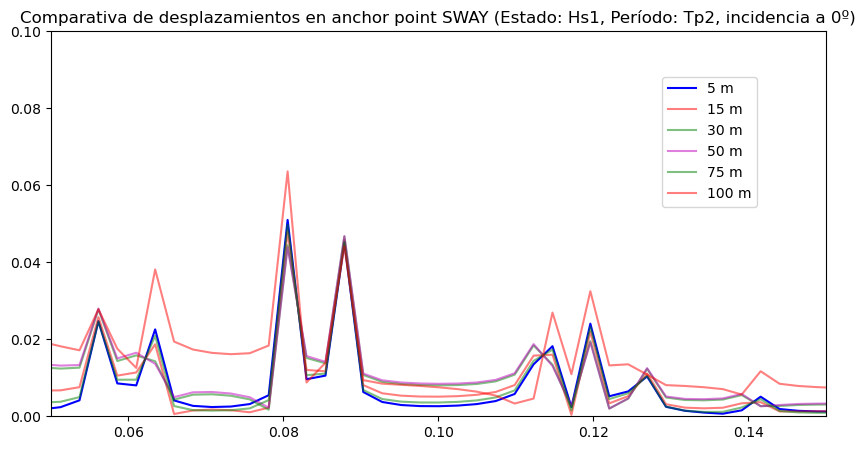

In [137]:
plt.figure(figsize=(10, 5))

plt.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'b', label = '5 m')
plt.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__3.xlsx'], color = 'r', label = '15 m',alpha=0.5)
plt.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__4.xlsx'], color = 'g', label = '30 m',alpha=0.5)
plt.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__5.xlsx'], color = 'm', label = '50 m',alpha=0.5)
plt.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__6.xlsx'], color = 'g', label = '75 m',alpha=0.5)
plt.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__7.xlsx'], color = 'r', label = '100 m',alpha=0.5)

plt.xlim(0.05,0.15)
plt.ylim(0,0.10)
plt.title('Comparativa de desplazamientos en anchor point SWAY (Estado: Hs1, Período: Tp2, incidencia a 0º)')
plt.legend(loc='upper center', bbox_to_anchor=(0.85, 0.9))

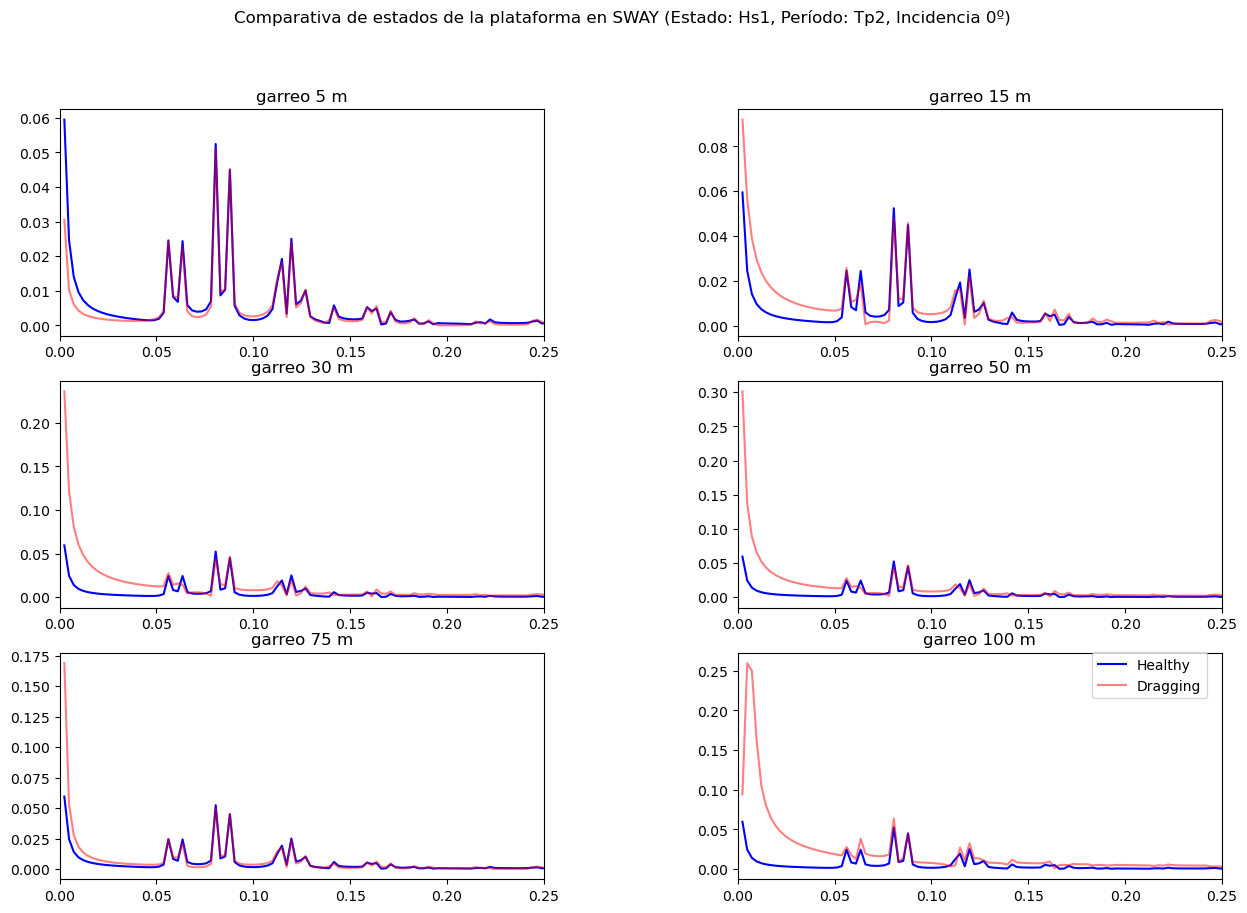

In [138]:
plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 1])

# Desempaqueta los ejes en variables individuales
garreo1 = plt.subplot(gs[0])
garreo2 = plt.subplot(gs[1])
garreo3 = plt.subplot(gs[2])
garreo4 = plt.subplot(gs[3])
garreo5 = plt.subplot(gs[4])
garreo6 = plt.subplot(gs[5])

#fig, axs = plt.subplots(nrows=2, ncols=2)

# Desempaqueta los ejes en variables individuales
#garreo1, garreo2, garreo3, garreo4 = axs.flatten()

garreo1.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo1.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo1.set_xlim(0,0.25)
garreo1.set_title('garreo 5 m')

garreo2.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo2.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__3.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo2.set_xlim(0,0.25)
garreo2.set_title('garreo 15 m')

garreo3.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo3.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__4.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo3.set_xlim(0,0.25)
garreo3.set_title('garreo 30 m')

garreo4.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo4.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__5.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo4.set_xlim(0,0.25)
garreo4.set_title('garreo 50 m')

garreo5.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo5.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__6.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo5.set_xlim(0,0.25)
garreo5.set_title('garreo 75 m')

garreo6.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo6.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__7.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo6.set_xlim(0,0.25)
garreo6.set_title('garreo 100 m')


plt.subplots_adjust(hspace=0.2, wspace=0.4)
plt.suptitle('Comparativa de estados de la plataforma en SWAY (Estado: Hs1, Período: Tp2, Incidencia 0º)')
plt.legend(['Healthy', 'Dragging'], loc='center', bbox_to_anchor=(0.85, 0.9))

In [142]:
columns = ['m2','m4']
stats_sway = pd.DataFrame(columns=columns)

for col in df_sway.columns[1:-3]:
    m2 = moment(df_sway[col], moment=2)
    m4 = moment(df_sway[col], moment=4)

    stats_sway.loc[col]=[m2,m4]

stats_sway.index=['health','5','15','30','50','75','100']

In [146]:
columns = ['m0','m2','m4']
stats_sway = pd.DataFrame(columns=columns)
freq = df_sway['Frequency'].values

for col in df_sway.columns[1:-3]:
    mov = df_sway[col].values
    m = prob_moment.Probability_Moment(mov,freq)

    m0 = m.momentn(0)
    m2 = m.momentn(2)
    m4 = m.momentn(4)

    stats_sway.loc[col]=[m0,m2,m4]

stats_sway.index=['healthy','5','15','30','50','75','100']

In [147]:
stats_sway

,m0,m2,m4
healthy,0.001732,0.072535,38.301696
5,0.001136,0.001048,0.282162
15,0.002850,0.158229,83.870317
30,0.005267,0.341677,181.287222
50,0.005745,0.367248,194.865118
75,0.002168,0.064045,33.838413
100,0.008718,0.617950,327.925604


In [71]:
momentos = ['m2','m4']
m2_dif_sway=[]
m4_dif_sway=[]

for m in momentos:
    health = stats_sway[m][0]
    for i in range(1,len(stats_sway)):
        dif = abs(stats_sway[m][i]-health)
        if m=='m2':
            m2_dif_sway.append(dif)
        else:
            m4_dif_sway.append(dif)

C:\Users\naval\AppData\Local\Temp\ipykernel_10100\2100989774.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  health = stats_sway[m][0]
C:\Users\naval\AppData\Local\Temp\ipykernel_10100\2100989774.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dif = abs(stats_sway[m][i]-health)


In [72]:
m2_dif_sway

[1.7712509705609265e-06,
 5.5362339921155845e-06,
 4.175274871235687e-05,
 6.247376181263839e-05,
 1.3667497347657064e-05,
 9.743280343713857e-05]

In [73]:
m4_dif_sway

[6.072489234362361e-09,
 3.331823831055061e-08,
 1.6174979399307408e-06,
 4.165070081338082e-06,
 3.9121615880527106e-07,
 4.439805319883873e-06]

vamos a representar la diferencia respecto al estado saludable de m2 y m4 de surge y sway

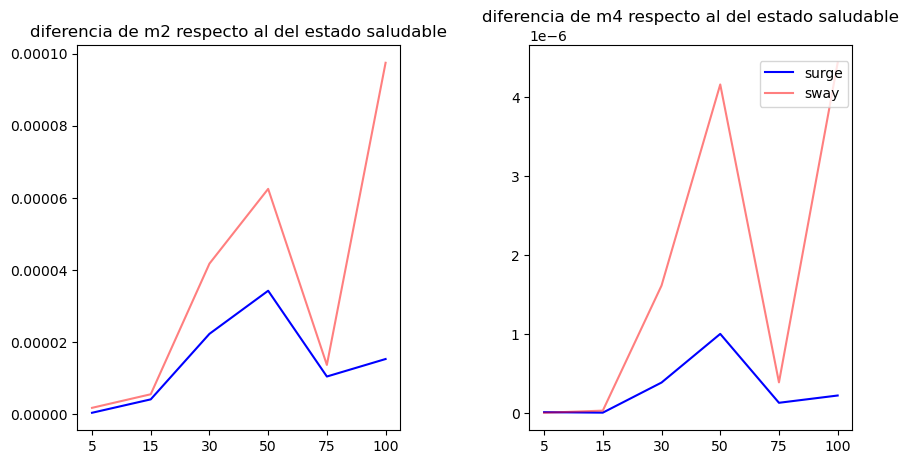

In [74]:
plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

# Desempaqueta los ejes en variables individuales
a = plt.subplot(gs[0])
b = plt.subplot(gs[1])

x = ['5','15','30','50','75','100']

a.plot(x,m2_dif_surge, color = 'b', label = 'surge')
a.plot(x,m2_dif_sway, color = 'r', label = 'sway',alpha=0.5)
#hs1_tp2.set_xlim(0,0.25)
a.set_title('diferencia de m2 respecto al del estado saludable')


b.plot(x,m4_dif_surge, color = 'b', label = 'surge')
b.plot(x,m4_dif_sway, color = 'r', label = 'sway',alpha=0.5)
#hs1_tp2.set_xlim(0,0.25)
b.set_title('diferencia de m4 respecto al del estado saludable')

plt.subplots_adjust(hspace=0.2, wspace=0.4)
plt.legend(['surge', 'sway'], loc='center', bbox_to_anchor=(0.85, 0.9))

## PRUEBAS CON LOS ESPECTROS DE ENERGÍA

In [156]:
ancho_banda = df_surge['Frequency'][2]-df_surge['Frequency'][1]

for e in df_surge.columns[1:]:
    df_surge[e] = 0.5 * (df_surge[e]**(2)*ancho_banda)

In [157]:
df_surge

,Frequency,oc4__Hs1__Tp2__dir1__1.xlsx,oc4__Hs1__Tp2__dir1__2.xlsx,oc4__Hs1__Tp2__dir1__3.xlsx,oc4__Hs1__Tp2__dir1__4.xlsx,oc4__Hs1__Tp2__dir1__5.xlsx,oc4__Hs1__Tp2__dir1__6.xlsx,oc4__Hs1__Tp2__dir1__7.xlsx,oc4__Hs1__Tp2__dir4__1.xlsx,oc4__Hs1__Tp2__dir4__3.xlsx,oc4__Hs1__Tp2__dir4__6.xlsx
1,0.002441,1.031245e-05,7.641631e-06,9.272635e-06,3.231037e-05,5.284252e-05,2.112728e-05,4.566619e-06,1.024079e-05,9.874819e-06,2.159676e-05
2,0.004883,1.391902e-06,1.694198e-06,5.120311e-06,1.399272e-05,1.804630e-05,6.920633e-06,2.421438e-05,1.610323e-06,5.439142e-06,7.014450e-06
3,0.007324,2.459812e-07,5.345634e-07,2.320629e-06,6.391036e-06,8.067083e-06,3.033710e-06,1.489306e-05,3.535908e-07,2.447721e-06,3.049991e-06
4,0.009766,7.130187e-08,2.583312e-07,1.302748e-06,3.607385e-06,4.527305e-06,1.689617e-06,8.753814e-07,1.308562e-07,1.361856e-06,1.682601e-06
5,0.012207,2.846627e-08,1.556469e-07,8.363053e-07,2.316618e-06,2.899105e-06,1.079808e-06,1.392943e-06,6.457196e-08,8.632144e-07,1.062511e-06
...,...,...,...,...,...,...,...,...,...,...,...
2044,4.990234,9.662498e-13,7.815130e-17,4.097080e-12,1.876849e-11,2.493332e-11,6.009958e-12,3.279379e-11,2.617437e-12,2.141779e-11,2.562438e-11
2045,4.992676,9.597392e-13,3.475689e-17,4.088462e-12,1.875565e-11,2.496308e-11,5.672408e-12,3.254040e-11,2.622609e-12,2.140733e-11,2.511560e-11
2046,4.995117,9.715248e-13,1.965342e-17,4.094721e-12,1.873737e-11,2.494378e-11,5.815073e-12,3.306482e-11,2.613264e-12,2.139951e-11,2.520813e-11
2047,4.997559,9.689950e-13,4.861197e-17,4.102268e-12,1.875869e-11,2.492310e-11,5.941227e-12,3.289780e-11,2.612487e-12,2.137506e-11,2.537842e-11


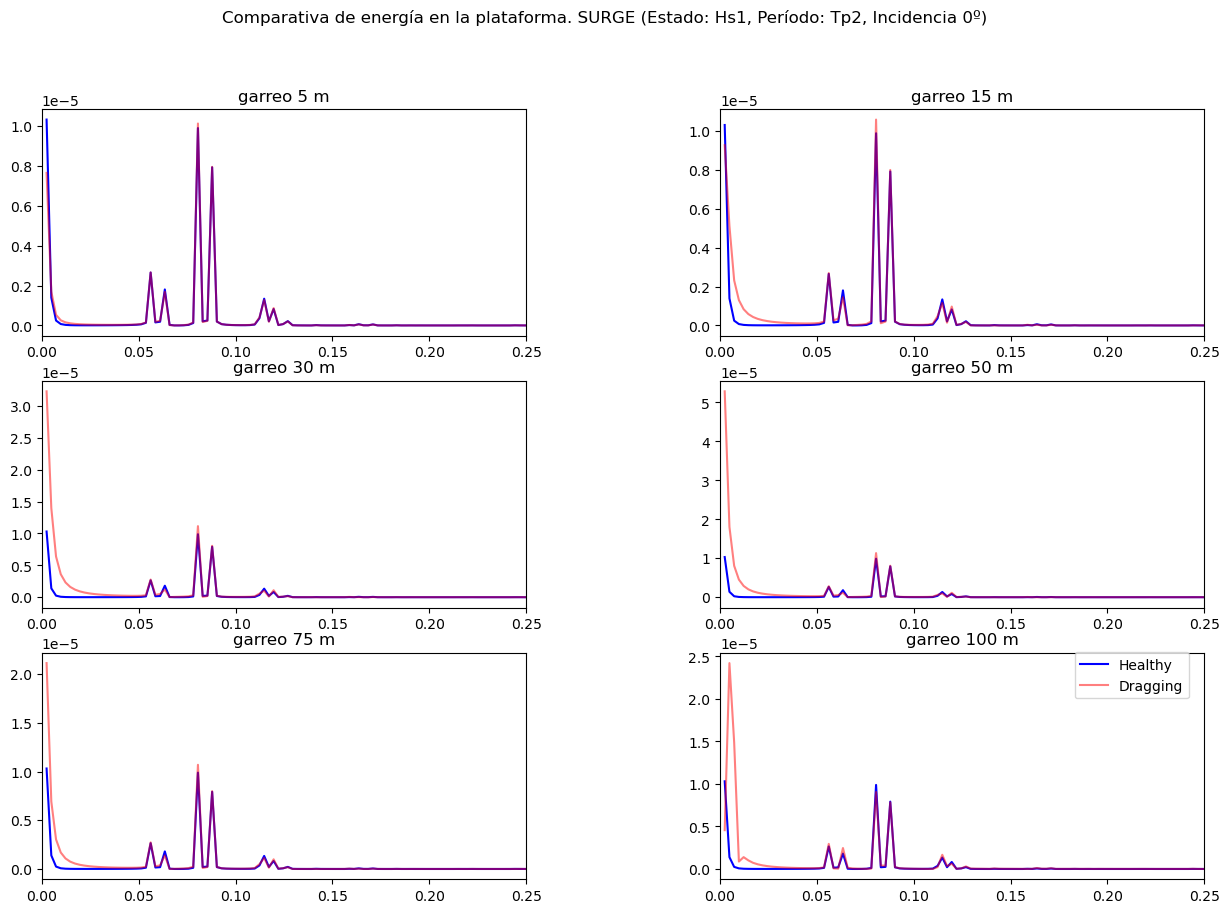

In [158]:
plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 1])

# Desempaqueta los ejes en variables individuales
garreo1 = plt.subplot(gs[0])
garreo2 = plt.subplot(gs[1])
garreo3 = plt.subplot(gs[2])
garreo4 = plt.subplot(gs[3])
garreo5 = plt.subplot(gs[4])
garreo6 = plt.subplot(gs[5])

#fig, axs = plt.subplots(nrows=2, ncols=2)

# Desempaqueta los ejes en variables individuales
#garreo1, garreo2, garreo3, garreo4 = axs.flatten()


garreo1.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo1.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo1.set_xlim(0,0.25)
garreo1.set_title('garreo 5 m')


garreo2.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo2.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__3.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo2.set_xlim(0,0.25)
garreo2.set_title('garreo 15 m')


garreo3.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo3.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__4.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo3.set_xlim(0,0.25)
garreo3.set_title('garreo 30 m')


garreo4.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo4.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__5.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo4.set_xlim(0,0.25)
garreo4.set_title('garreo 50 m')


garreo5.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo5.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__6.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo5.set_xlim(0,0.25)
garreo5.set_title('garreo 75 m')

garreo6.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo6.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__7.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo6.set_xlim(0,0.25)
garreo6.set_title('garreo 100 m')

plt.subplots_adjust(hspace=0.2, wspace=0.4)
plt.suptitle('Comparativa de energía en la plataforma. SURGE (Estado: Hs1, Período: Tp2, Incidencia 0º)')
plt.legend(['Healthy', 'Dragging'], loc='center', bbox_to_anchor=(0.85, 0.9))

In [161]:
columns = ['m2','m4']
stats_surge = pd.DataFrame(columns=columns)
for col in df_surge.columns[1:-3]:
    m2 = moment(df_surge[col], moment=2)
    m4 = moment(df_surge[col], moment=4)

    stats_surge.loc[col]=[m2,m4]

stats_surge.index=['healthy','5','15','30','50','75','100']

In [163]:
columns = ['m0','m2','m4']
stats_surge = pd.DataFrame(columns=columns)
freq = df_surge['Frequency'].values

for col in df_surge.columns[1:-3]:
    mov = df_surge[col].values
    m = prob_moment.Probability_Moment(mov,freq)

    m0 = m.momentn(0)
    m2 = m.momentn(2)
    m4 = m.momentn(4)

    stats_surge.loc[col]=[m0,m2,m4]

stats_surge.index=['healthy','5','15','30','50','75','100']

In [164]:
stats_surge

,m0,m2,m4
healthy,9.624673e-08,2.198557e-08,1.120240e-06
5,9.363348e-08,1.941882e-08,7.486356e-09
15,1.226354e-07,3.100825e-08,4.694636e-06
30,2.366092e-07,7.199590e-08,2.151932e-05
50,3.108582e-07,8.921671e-08,2.860299e-05
75,1.619018e-07,3.603644e-08,6.755688e-06
100,1.943139e-07,1.100124e-07,3.763188e-05


Ahora con sway

In [78]:
ancho_banda = df_sway['Frequency'][2]-df_sway['Frequency'][1]

for e in df_sway.columns[1:]:
    df_sway[e] = 0.5 * (df_sway[e]**(2)*ancho_banda)

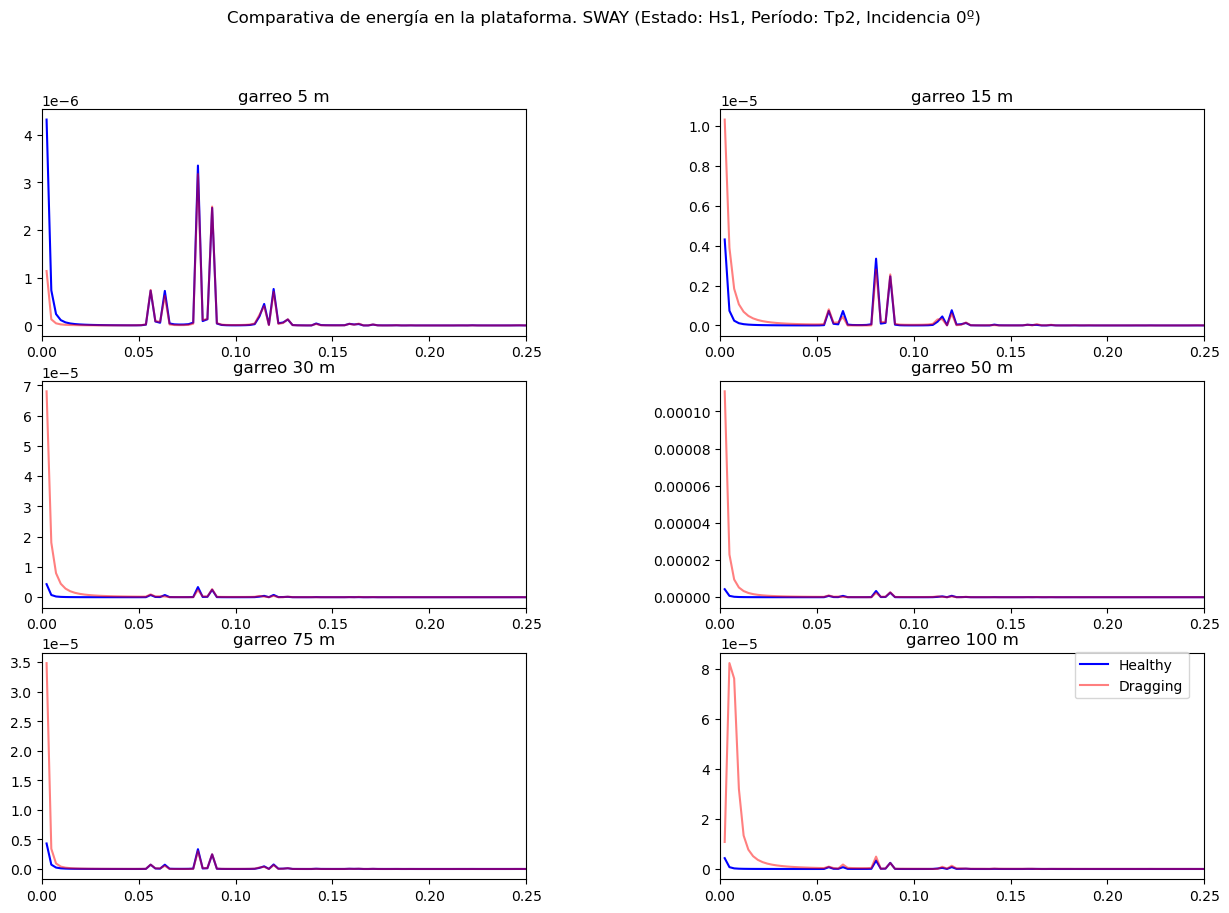

In [92]:
plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 1])

# Desempaqueta los ejes en variables individuales
garreo1 = plt.subplot(gs[0])
garreo2 = plt.subplot(gs[1])
garreo3 = plt.subplot(gs[2])
garreo4 = plt.subplot(gs[3])
garreo5 = plt.subplot(gs[4])
garreo6 = plt.subplot(gs[5])

#fig, axs = plt.subplots(nrows=2, ncols=2)

# Desempaqueta los ejes en variables individuales
#garreo1, garreo2, garreo3, garreo4 = axs.flatten()


garreo1.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo1.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo1.set_xlim(0,0.25)
garreo1.set_title('garreo 5 m')


garreo2.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo2.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__3.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo2.set_xlim(0,0.25)
garreo2.set_title('garreo 15 m')


garreo3.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo3.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__4.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo3.set_xlim(0,0.25)
garreo3.set_title('garreo 30 m')


garreo4.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo4.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__5.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo4.set_xlim(0,0.25)
garreo4.set_title('garreo 50 m')


garreo5.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo5.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__6.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo5.set_xlim(0,0.25)
garreo5.set_title('garreo 75 m')

garreo6.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo6.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__7.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo6.set_xlim(0,0.25)
garreo6.set_title('garreo 100 m')

plt.subplots_adjust(hspace=0.2, wspace=0.4)
plt.suptitle('Comparativa de energía en la plataforma. SWAY (Estado: Hs1, Período: Tp2, Incidencia 0º)')
plt.legend(['Healthy', 'Dragging'], loc='center', bbox_to_anchor=(0.85, 0.9))

In [84]:
columns = ['m2','m4']
stats_surge = pd.DataFrame(columns=columns)
for col in df_surge.columns[1:-3]:
    m2 = moment(df_surge[col], moment=2)
    m4 = moment(df_surge[col], moment=4)

    stats_surge.loc[col]=[m2,m4]

stats_surge.index=['health','5','15','30','50','75','100']

In [85]:
columns = ['m2','m4']
stats_sway = pd.DataFrame(columns=columns)
for col in df_sway.columns[1:-3]:
    m2 = moment(df_sway[col], moment=2)
    m4 = moment(df_sway[col], moment=4)

    stats_sway.loc[col]=[m2,m4]

stats_sway.index=['health','5','15','30','50','75','100']

In [86]:
momentos = ['m2','m4']
m2_dif_surge=[]
m4_dif_surge=[]

for m in momentos:
    health = stats_surge[m][0]
    for i in range(1,len(stats_surge)):
        dif = abs(stats_surge[m][i]-health)
        if m=='m2':
            m2_dif_surge.append(dif)
        else:
            m4_dif_surge.append(dif)

C:\Users\naval\AppData\Local\Temp\ipykernel_10100\2824797089.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  health = stats_surge[m][0]
C:\Users\naval\AppData\Local\Temp\ipykernel_10100\2824797089.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dif = abs(stats_surge[m][i]-health)


In [87]:
momentos = ['m2','m4']
m2_dif_sway=[]
m4_dif_sway=[]

for m in momentos:
    health = stats_sway[m][0]
    for i in range(1,len(stats_sway)):
        dif = abs(stats_sway[m][i]-health)
        if m=='m2':
            m2_dif_sway.append(dif)
        else:
            m4_dif_sway.append(dif)

C:\Users\naval\AppData\Local\Temp\ipykernel_10100\2100989774.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  health = stats_sway[m][0]
C:\Users\naval\AppData\Local\Temp\ipykernel_10100\2100989774.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dif = abs(stats_sway[m][i]-health)


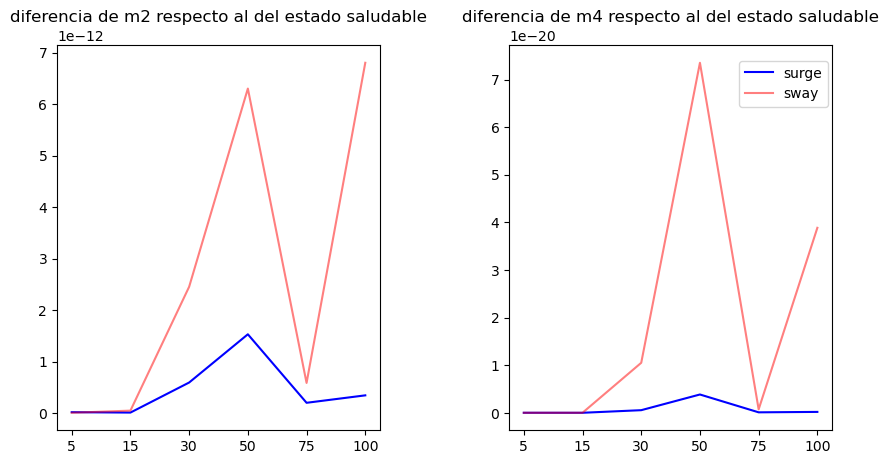

In [91]:
plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

# Desempaqueta los ejes en variables individuales
a = plt.subplot(gs[0])
b = plt.subplot(gs[1])

x = ['5','15','30','50','75','100']

a.plot(x,m2_dif_surge, color = 'b', label = 'surge')
a.plot(x,m2_dif_sway, color = 'r', label = 'sway',alpha=0.5)
#hs1_tp2.set_xlim(0,0.25)
a.set_title('diferencia de m2 respecto al del estado saludable')


b.plot(x,m4_dif_surge, color = 'b', label = 'surge')
b.plot(x,m4_dif_sway, color = 'r', label = 'sway',alpha=0.5)
#hs1_tp2.set_xlim(0,0.25)
b.set_title('diferencia de m4 respecto al del estado saludable')

plt.subplots_adjust(hspace=0.2, wspace=0.4)
plt.legend(['surge', 'sway'], loc='center', bbox_to_anchor=(0.85, 0.9))

In [89]:
m4_dif_surge

[3.363615917550484e-24,
 4.017664899322987e-26,
 5.458321864926307e-22,
 3.840466441556225e-21,
 9.40710484806255e-23,
 1.8381721755758543e-22]

In [3]:
dt=0.1
freq_test = np.arange(0.2,2.1,dt)
spec = np.array([0.000, 0.035, 17.806, 55.967, 50.662, 33.229, 20.181, 12.254, 7.614, 4.877, 3.220, 2.186, 1.521, 1.085, 0.789, 0.584, 0.440, 0.336, 0.261])

In [4]:
m = prob_moment.Probability_Moment(spec,freq_test)

m0 = m.momentn(0)
m2 = m.momentn(2)
m4 = m.momentn(4)

In [5]:
m0

21.304700000000008

In [7]:
m2

10.88648500000001

In [8]:
m4

9.703699450000013

el metodo de fatiguepy si determine bien los momentos espectrales. Lo he comprobado con un ejercicio que tenía del máster

In [194]:
spec2 = np.array([0.04368,0.40378, 0.32900, 0.13033, 0.03950, 0.01247, 0.00542, 0.00100, 0.00302, 0.00000, 0.00000])
freq_test2 = np.arange(0.3,2.5,0.2)

In [202]:
m = prob_moment.Probability_Moment(spec2,freq_test2)

m0 = m.momentn(0)
m2 = m.momentn(1)
m4 = m.momentn(4)

In [204]:
m0

0.19364

## Comportamiento de los moviminetos probando a mover otra linea. Condición de surge crítico

Queremos ver si hay variaciones más notorias en otra línea de fondeo

### Surge

In [11]:
path = rf'D:\arturo_sim\simulaciones\acoplado\analisis_limite_garreo\análisis_2'
movements = ['Surge','Sway']
dataframes_surge = {}
dataframes_sway = {}

for mov in movements:
    direc = os.listdir(os.path.join(path,mov))
    for file in direc:
        file_path = os.path.join(path, mov, file)
        df = pd.read_excel(file_path, header=1).drop(0)

        # Almaceno los resultados del número de simulaciones empleado
        if mov == 'Surge':
            dataframes_surge[f'{file}'] = df
        else:
            dataframes_sway[f'{file}'] = df

In [12]:
dataframes_surge['oc4__Hs1__Tp2__dir1__2.xlsx']

,Frequencies),Amplitude
1,0.002441,0.060370
2,0.004883,0.025339
3,0.007324,0.014307
4,0.009766,0.009937
5,0.012207,0.007758
...,...,...
2044,4.990234,0.000031
2045,4.992676,0.000031
2046,4.995117,0.000031
2047,4.997559,0.000031


In [18]:
df_surge = pd.concat(dataframes_surge.values(), axis=1)
df_sway = pd.concat(dataframes_sway.values(), axis=1)

In [19]:
df_surge

,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude
1,0.002441,0.091269,0.002441,0.060370,0.002441,0.060938,0.002441,0.510477,0.002441,3.356354,0.002441,0.264555,0.002441,0.194923
2,0.004883,0.036160,0.004883,0.025339,0.004883,0.026427,0.004883,0.320411,0.004883,1.723377,0.004883,0.340381,0.004883,0.375432
3,0.007324,0.017166,0.007324,0.014307,0.007324,0.015372,0.007324,0.220147,0.007324,1.152308,0.007324,0.155944,0.007324,0.223702
4,0.009766,0.010515,0.009766,0.009937,0.009766,0.010752,0.009766,0.166695,0.009766,0.865150,0.009766,0.084210,0.009766,0.149303
5,0.012207,0.007534,0.012207,0.007758,0.012207,0.008391,0.012207,0.134017,0.012207,0.692549,0.012207,0.055416,0.012207,0.113035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2044,4.990234,0.000039,4.990234,0.000031,4.990234,0.000029,4.990234,0.000461,4.990234,0.002601,4.990234,0.000197,4.990234,0.000453
2045,4.992676,0.000039,4.992676,0.000031,4.992676,0.000029,4.992676,0.000460,4.992676,0.002601,4.992676,0.000196,4.992676,0.000454
2046,4.995117,0.000039,4.995117,0.000031,4.995117,0.000029,4.995117,0.000460,4.995117,0.002602,4.995117,0.000197,4.995117,0.000453
2047,4.997559,0.000039,4.997559,0.000031,4.997559,0.000029,4.997559,0.000461,4.997559,0.002602,4.997559,0.000197,4.997559,0.000453


In [20]:
df_freq = df_surge.iloc[:,0]
df_surge = df_surge.drop(df_surge.filter(like='Frequencies)').columns, axis=1)
df_surge.insert(0,'Frequency',df_freq)

In [21]:
path_surge = rf'D:\arturo_sim\simulaciones\acoplado\analisis_limite_garreo\análisis_2\Surge'
lista_archivos = os.listdir(path_surge)

if len(lista_archivos) == (len(df_surge.columns) - 1):
    df_surge.columns = ['Frequency'] + lista_archivos

In [22]:
df_surge

,Frequency,oc4__Hs1__Tp2__dir1__1.xlsx,oc4__Hs1__Tp2__dir1__2.xlsx,oc4__Hs1__Tp2__dir1__3.xlsx,oc4__Hs1__Tp2__dir1__4.xlsx,oc4__Hs1__Tp2__dir1__5.xlsx,oc4__Hs1__Tp2__dir1__6.xlsx,oc4__Hs1__Tp2__dir1__7.xlsx
1,0.002441,0.091269,0.060370,0.060938,0.510477,3.356354,0.264555,0.194923
2,0.004883,0.036160,0.025339,0.026427,0.320411,1.723377,0.340381,0.375432
3,0.007324,0.017166,0.014307,0.015372,0.220147,1.152308,0.155944,0.223702
4,0.009766,0.010515,0.009937,0.010752,0.166695,0.865150,0.084210,0.149303
5,0.012207,0.007534,0.007758,0.008391,0.134017,0.692549,0.055416,0.113035
...,...,...,...,...,...,...,...,...
2044,4.990234,0.000039,0.000031,0.000029,0.000461,0.002601,0.000197,0.000453
2045,4.992676,0.000039,0.000031,0.000029,0.000460,0.002601,0.000196,0.000454
2046,4.995117,0.000039,0.000031,0.000029,0.000460,0.002602,0.000197,0.000453
2047,4.997559,0.000039,0.000031,0.000029,0.000461,0.002602,0.000197,0.000453


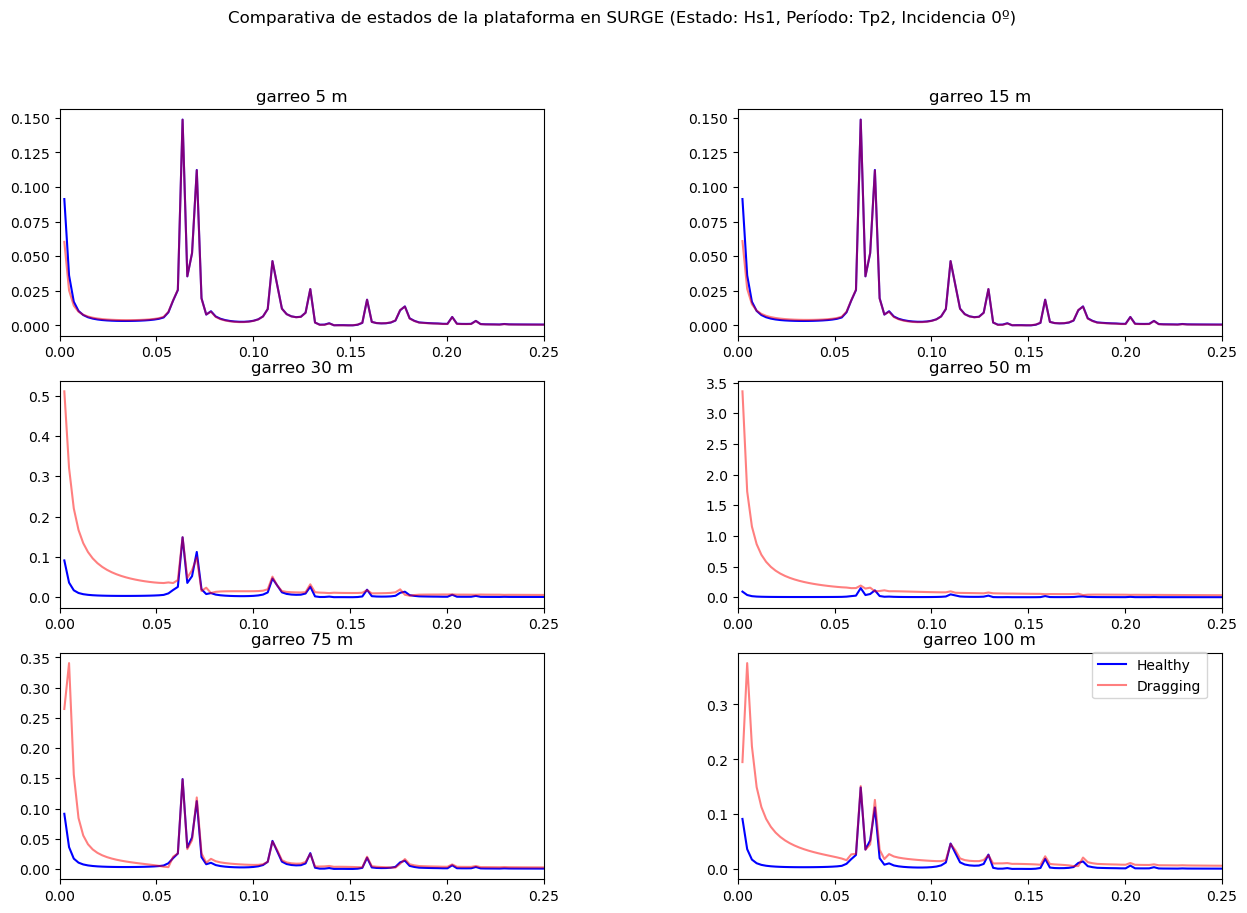

In [23]:
plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 1])

# Desempaqueta los ejes en variables individuales
garreo1 = plt.subplot(gs[0])
garreo2 = plt.subplot(gs[1])
garreo3 = plt.subplot(gs[2])
garreo4 = plt.subplot(gs[3])
garreo5 = plt.subplot(gs[4])
garreo6 = plt.subplot(gs[5])

#fig, axs = plt.subplots(nrows=2, ncols=2)

# Desempaqueta los ejes en variables individuales
#garreo1, garreo2, garreo3, garreo4 = axs.flatten()


garreo1.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo1.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo1.set_xlim(0,0.25)
garreo1.set_title('garreo 5 m')


garreo2.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo2.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__3.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo2.set_xlim(0,0.25)
garreo2.set_title('garreo 15 m')


garreo3.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo3.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__4.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo3.set_xlim(0,0.25)
garreo3.set_title('garreo 30 m')


garreo4.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo4.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__5.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo4.set_xlim(0,0.25)
garreo4.set_title('garreo 50 m')


garreo5.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo5.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__6.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo5.set_xlim(0,0.25)
garreo5.set_title('garreo 75 m')

garreo6.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo6.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__7.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo6.set_xlim(0,0.25)
garreo6.set_title('garreo 100 m')

plt.subplots_adjust(hspace=0.2, wspace=0.4)
plt.suptitle('Comparativa de estados de la plataforma en SURGE (Estado: Hs1, Período: Tp2, Incidencia 0º)')
plt.legend(['Healthy', 'Dragging'], loc='center', bbox_to_anchor=(0.85, 0.9))

In [25]:
columns = ['m0','m2','m4']
stats_surge = pd.DataFrame(columns=columns)
freq = df_surge['Frequency'].values

for col in df_surge.columns[1:]:
    mov = df_surge[col].values
    m = prob_moment.Probability_Moment(mov,freq)

    m0 = m.momentn(0)
    m2 = m.momentn(2)
    m4 = m.momentn(4)

    stats_surge.loc[col]=[m0,m2,m4]

stats_surge.index=['healthy','5','15','30','50','75','100']

In [26]:
stats_surge

,m0,m2,m4
healthy,0.002830,0.001954,0.025986
5,0.002648,0.001552,0.020582
15,0.002645,0.001455,0.019277
30,0.013599,0.023026,0.309547
50,0.070592,0.129964,1.747514
75,0.007174,0.009831,0.131959
100,0.012277,0.022655,0.304444


In [27]:
momentos = ['m2','m4']
m2_dif_surge=[]
m4_dif_surge=[]

for m in momentos:
    health = stats_surge[m][0]
    for i in range(1,len(stats_surge)):
        dif = abs(stats_surge[m][i]-health)
        if m=='m2':
            m2_dif_surge.append(dif)
        else:
            m4_dif_surge.append(dif)

C:\Users\naval\AppData\Local\Temp\ipykernel_7744\2824797089.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  health = stats_surge[m][0]
C:\Users\naval\AppData\Local\Temp\ipykernel_7744\2824797089.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dif = abs(stats_surge[m][i]-health)


In [28]:
m2_dif_surge

[0.0004012497509141063,
 0.0004981916231358162,
 0.02107212428122136,
 0.12801041369781543,
 0.007877212051226035,
 0.02070179851627345]

In [29]:
m4_dif_surge

[0.005403691198643968,
 0.0067080948949256244,
 0.28356138221406,
 1.7215283989406451,
 0.10597325318760707,
 0.27845886824963834]

### Sway

In [30]:
df_freq = df_sway.iloc[:,0]
df_sway = df_sway.drop(df_sway.filter(like='Frequencies)').columns, axis=1)
df_sway.insert(0,'Frequency',df_freq)

In [31]:
path_sway = rf'D:\arturo_sim\simulaciones\acoplado\analisis_limite_garreo\análisis_2\Sway'
lista_archivos = os.listdir(path_sway)

if len(lista_archivos) == (len(df_sway.columns) - 1):
    df_sway.columns = ['Frequency'] + lista_archivos

In [32]:
df_sway

,Frequency,oc4__Hs1__Tp2__dir1__1.xlsx,oc4__Hs1__Tp2__dir1__2.xlsx,oc4__Hs1__Tp2__dir1__3.xlsx,oc4__Hs1__Tp2__dir1__4.xlsx,oc4__Hs1__Tp2__dir1__5.xlsx,oc4__Hs1__Tp2__dir1__6.xlsx,oc4__Hs1__Tp2__dir1__7.xlsx
1,0.002441,0.060308,0.082914,0.109917,0.714556,1.913758,0.032447,0.023927
2,0.004883,0.024807,0.028552,0.066499,0.378334,0.955688,0.026035,0.018512
3,0.007324,0.014087,0.013945,0.045028,0.254368,0.637932,0.029426,0.033400
4,0.009766,0.009653,0.008593,0.033901,0.191320,0.478677,0.018072,0.022112
5,0.012207,0.007347,0.006055,0.027157,0.153247,0.383022,0.010511,0.015333
...,...,...,...,...,...,...,...,...
2044,4.990234,0.000023,0.000015,0.000107,0.000591,0.001472,0.000013,0.000043
2045,4.992676,0.000023,0.000015,0.000107,0.000591,0.001472,0.000013,0.000043
2046,4.995117,0.000023,0.000015,0.000107,0.000591,0.001471,0.000013,0.000043
2047,4.997559,0.000023,0.000015,0.000107,0.000591,0.001472,0.000013,0.000043


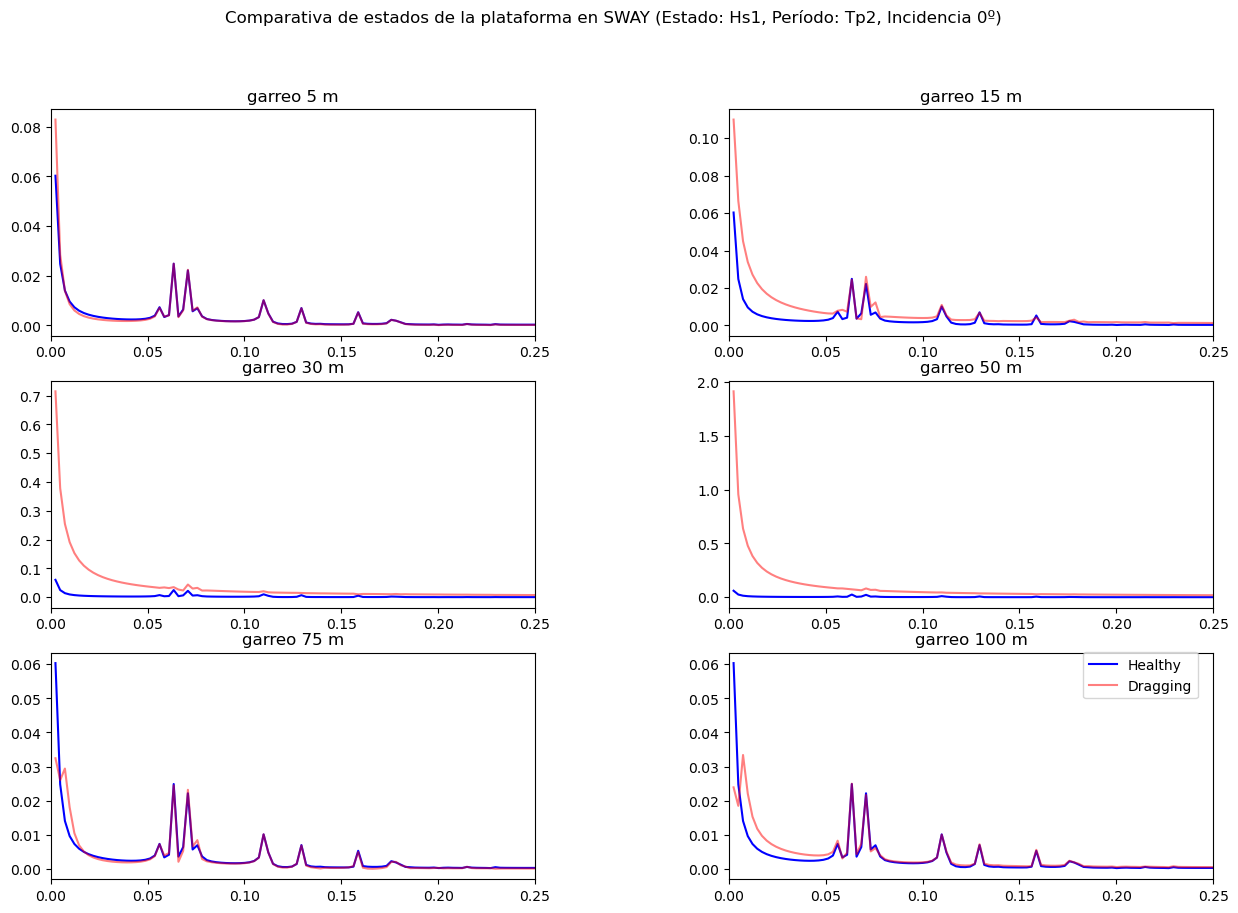

In [41]:
plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 1])

# Desempaqueta los ejes en variables individuales
garreo1 = plt.subplot(gs[0])
garreo2 = plt.subplot(gs[1])
garreo3 = plt.subplot(gs[2])
garreo4 = plt.subplot(gs[3])
garreo5 = plt.subplot(gs[4])
garreo6 = plt.subplot(gs[5])

#fig, axs = plt.subplots(nrows=2, ncols=2)

# Desempaqueta los ejes en variables individuales
#garreo1, garreo2, garreo3, garreo4 = axs.flatten()

garreo1.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo1.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo1.set_xlim(0,0.25)
garreo1.set_title('garreo 5 m')

garreo2.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo2.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__3.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo2.set_xlim(0,0.25)
garreo2.set_title('garreo 15 m')

garreo3.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo3.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__4.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo3.set_xlim(0,0.25)
garreo3.set_title('garreo 30 m')

garreo4.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo4.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__5.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo4.set_xlim(0,0.25)
garreo4.set_title('garreo 50 m')

garreo5.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo5.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__6.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo5.set_xlim(0,0.25)
garreo5.set_title('garreo 75 m')

garreo6.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
garreo6.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__7.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo6.set_xlim(0,0.25)
garreo6.set_title('garreo 100 m')


plt.subplots_adjust(hspace=0.2, wspace=0.4)
plt.suptitle('Comparativa de estados de la plataforma en SWAY (Estado: Hs1, Período: Tp2, Incidencia 0º)')
plt.legend(['Healthy', 'Dragging'], loc='center', bbox_to_anchor=(0.85, 0.9))

In [34]:
columns = ['m0','m2','m4']
stats_sway = pd.DataFrame(columns=columns)
freq = df_sway['Frequency'].values

for col in df_sway.columns[1:]:
    mov = df_sway[col].values
    m = prob_moment.Probability_Moment(mov,freq)

    m0 = m.momentn(0)
    m2 = m.momentn(2)
    m4 = m.momentn(4)

    stats_sway.loc[col]=[m0,m2,m4]

stats_sway.index=['healthy','5','15','30','50','75','100']

In [35]:
stats_sway

,m0,m2,m4
healthy,0.001091,0.001169,0.015670
5,0.001018,0.000774,0.010353
15,0.002982,0.005360,0.072053
30,0.015792,0.029542,0.397206
50,0.039557,0.073516,0.988483
75,0.000947,0.000660,0.008828
100,0.001442,0.002143,0.028782


In [36]:
momentos = ['m2','m4']
m2_dif_sway=[]
m4_dif_sway=[]

for m in momentos:
    health = stats_sway[m][0]
    for i in range(1,len(stats_sway)):
        dif = abs(stats_sway[m][i]-health)
        if m=='m2':
            m2_dif_sway.append(dif)
        else:
            m4_dif_sway.append(dif)

C:\Users\naval\AppData\Local\Temp\ipykernel_7744\2100989774.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  health = stats_sway[m][0]
C:\Users\naval\AppData\Local\Temp\ipykernel_7744\2100989774.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dif = abs(stats_sway[m][i]-health)


In [37]:
m2_dif_sway

[0.00039503885639620613,
 0.004191846748239379,
 0.028373291027630042,
 0.07234784317521531,
 0.0005084173431521286,
 0.000974769863265176]

In [38]:
m4_dif_sway

[0.005316196322720892,
 0.05638317185690729,
 0.3815366593949808,
 0.9728134690121859,
 0.006841366007997486,
 0.01311236704708266]

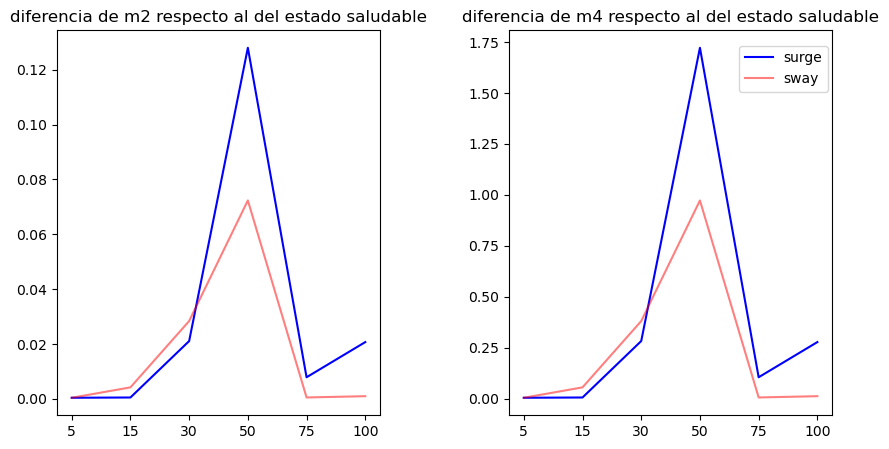

In [39]:
plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

# Desempaqueta los ejes en variables individuales
a = plt.subplot(gs[0])
b = plt.subplot(gs[1])

x = ['5','15','30','50','75','100']

a.plot(x,m2_dif_surge, color = 'b', label = 'surge')
a.plot(x,m2_dif_sway, color = 'r', label = 'sway',alpha=0.5)
#hs1_tp2.set_xlim(0,0.25)
a.set_title('diferencia de m2 respecto al del estado saludable')


b.plot(x,m4_dif_surge, color = 'b', label = 'surge')
b.plot(x,m4_dif_sway, color = 'r', label = 'sway',alpha=0.5)
#hs1_tp2.set_xlim(0,0.25)
b.set_title('diferencia de m4 respecto al del estado saludable')

plt.subplots_adjust(hspace=0.2, wspace=0.4)
plt.legend(['surge', 'sway'], loc='center', bbox_to_anchor=(0.85, 0.9))